# Dự án Học máy — Dự đoán thời điểm tái đặt hàng của nhà thuốc (PharmaDist)

**Họ và tên:** Hoàng Phi Hải &nbsp;&nbsp;|&nbsp;&nbsp; **Mã số sinh viên:** 25MS23323

---

## 1. Bối cảnh và mục tiêu

PharmaDist là một nhà phân phối dược phẩm B2B, cung cấp thuốc và thực phẩm chức năng cho mạng lưới nhà thuốc trên cả ba miền. Doanh nghiệp mong muốn dự đoán **thời điểm mỗi nhà thuốc phát sinh đơn hàng tiếp theo**, nhằm giúp đội ngũ trình dược viên chủ động chăm sóc khách hàng trước khi họ ngừng giao dịch và chuyển sang nhà phân phối khác.

Từ 7 tập dữ liệu thô, dự án xây dựng một quy trình hoàn chỉnh: khám phá, làm sạch, tích hợp, tạo đặc trưng, xây dựng nhãn mục tiêu, huấn luyện — đánh giá mô hình và đưa ra khuyến nghị.

**Biến mục tiêu** (thực hiện cả hai bài toán):
- `days_until_next_order` — số ngày đến đơn hàng kế tiếp (bài toán **hồi quy**).
- `will_reorder_within_45_days` — khả năng tái đặt hàng trong 45 ngày (bài toán **phân loại**).

## 2. Quy trình thực hiện

| Bước | Nội dung |
|---|---|
| 0 | Xác định bài toán và ràng buộc của đề bài |
| **1** | **Phân tích khám phá dữ liệu (EDA) — nội dung của notebook này** |
| 2 | Làm sạch dữ liệu (giá trị thiếu, ngoại lai, định dạng ngày, ràng buộc logic) |
| 2.5 | Tích hợp 7 bảng và tính `total_amount` |
| 3 | Biến đổi dữ liệu (chuẩn hóa, mã hóa) |
| 4 | Xây dựng đặc trưng (RFM và các nhóm hành vi) |
| 4.5 | Xây dựng nhãn mục tiêu và xử lý hiện tượng censoring |
| 5 | Phân chia dữ liệu theo thời gian (chống rò rỉ) |
| 6 | Huấn luyện (hồi quy tuyến tính / logistic) và đánh giá |
| 7 | Báo cáo và khuyến nghị |

> **Nguyên tắc xuyên suốt — chống rò rỉ dữ liệu (data leakage):** mọi tham số ước lượng từ dữ liệu (giá trị điền khuyết, trung bình/độ lệch chuẩn để chuẩn hóa, danh mục để mã hóa) chỉ được học trên **tập huấn luyện** rồi áp dụng cho tập kiểm tra. Riêng bước EDA chỉ **quan sát**, chưa thực hiện biến đổi dữ liệu.

## 3. Bước 0 — Xác định ràng buộc của đề bài

Trước khi khảo sát dữ liệu, cần xác định các ràng buộc bắt buộc nêu trong đề bài. Mỗi ràng buộc vừa quy định phương pháp được phép sử dụng, vừa định hướng nội dung cần tập trung khảo sát trong phần EDA.

| Ràng buộc của đề bài | Hệ quả về phương pháp | Nội dung EDA cần khảo sát |
|---|---|---|
| Chỉ dùng hồi quy tuyến tính / logistic (không dùng cây quyết định, XGBoost, SHAP) | Độ quan trọng đặc trưng được đo bằng độ lớn standardized coefficient | Multicollinearity (corr/VIF) và quan hệ phi tuyến |
| Phân chia dữ liệu theo thời gian | Không dùng phân chia ngẫu nhiên | Drift giữa giai đoạn cũ và mới; mốc thời gian cắt |
| Nhãn mục tiêu phải tự xây dựng | Suy ra nhãn từ mốc thời gian | Độ phủ đơn hàng và hiện tượng censoring |
| Dữ liệu gồm 7 bảng | Phải tích hợp, phân biệt LEFT/INNER JOIN | Toàn bộ quan hệ khóa giữa các bảng |
| Lớp mục tiêu mất cân bằng | Dùng F1 / PR-AUC thay cho Accuracy | Kiểm tra mức độ cân bằng lớp |

> Cần phân biệt hai loại ràng buộc: **(i) ràng buộc từ đề bài** — biết trước khi tiếp cận dữ liệu; **(ii) ràng buộc do dữ liệu bộc lộ** (mất cân bằng lớp, multicollinearity, cửa sổ rò rỉ thời gian, số lượng bản ghi bị censoring) — chỉ phát hiện được qua EDA. Loại (i) định hướng cho EDA nhằm phát hiện loại (ii) đúng trọng tâm.

## 4. Bước 1 — Phân tích khám phá dữ liệu (EDA)

Phần phân tích được tổ chức thành ba phần:
- **Phần A** — khảo sát từng bảng dữ liệu (tổng quan, phân phối, giá trị thiếu, ngoại lai, ràng buộc miền giá trị).
- **Phần B** — khảo sát quan hệ giữa các bảng (tính toàn vẹn khóa, hiện tượng censoring).
- **Phần C** — khảo sát theo định hướng mô hình (multicollinearity, drift theo thời gian).

Kết quả của bước này là **bảng tổng hợp các vấn đề dữ liệu**, làm đầu vào cho bước làm sạch.

### 4.1. Thiết lập môi trường và nạp dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings, re
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

DATA_DIR = '../HW/'
FILES = ['pharmacies', 'orders', 'order_lines', 'products',
         'support_tickets', 'sales_engagements', 'warehouses']
data = {f: pd.read_csv(DATA_DIR + f + '.csv') for f in FILES}

REF_DATE = pd.Timestamp.now().normalize()   # mốc thời gian tham chiếu (động, không cố định năm)

def make_grid(n, ncol=3, h=3.5):
    '''Tạo lưới subplot tự động đủ ô cho n biểu đồ (số hàng tính theo n),
    bảo đảm không bỏ sót đối tượng nào khi vẽ theo vòng lặp.'''
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(16, h * nrow))
    return fig, np.atleast_1d(axes).ravel()

print('Đã nạp', len(data), 'bảng dữ liệu. Mốc tham chiếu:', REF_DATE.date())
for f in FILES:
    print(f'  {f:20s} {data[f].shape}')

Đã nạp 7 bảng dữ liệu. Mốc tham chiếu: 2026-06-27
  pharmacies           (800, 8)
  orders               (3500, 8)
  order_lines          (7740, 4)
  products             (150, 7)
  support_tickets      (700, 7)
  sales_engagements    (1800, 8)
  warehouses           (25, 5)


### 4.2. Phần A — Khảo sát từng bảng

#### A0. Tổng quan từng bảng
Khảo sát kích thước, kiểu dữ liệu, tỷ lệ thiếu, số giá trị duy nhất và thống kê mô tả của các cột số.

In [2]:
def overview(name, df):
    print('='*72)
    print(f'Bảng: {name}.csv   |   {df.shape[0]} dòng × {df.shape[1]} cột')
    print('-'*72)
    info = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_unique': df.nunique(),
        'missing_%': (df.isnull().mean()*100).round(2),
    })
    print(info.to_string())

for f in FILES:
    overview(f, data[f]); print()

Bảng: pharmacies.csv   |   800 dòng × 8 cột
------------------------------------------------------------------------
                       dtype  n_unique  missing_%
pharmacy_id           object       800       0.00
pharmacy_type         object         6       5.62
establishment_year   float64        34       4.12
province              object        24       4.12
region                object         3       0.00
onboarding_date       object       698       0.00
acquisition_channel   object         4       4.62
credit_tier           object         3       5.88

Bảng: orders.csv   |   3500 dòng × 8 cột
------------------------------------------------------------------------
                    dtype  n_unique  missing_%
order_id           object      3500       0.00
pharmacy_id        object       690       0.00
warehouse_id       object        25       0.00
order_date         object      1812       0.00
payment_term       object         3       4.97
payment_method     object         4 

In [3]:
# Thống kê mô tả các cột số: xu hướng trung tâm (mean) và độ biến thiên (std, quartile)
for f in FILES:
    num = data[f].select_dtypes(include='number')
    if num.shape[1]:
        print(f'----- {f}: thống kê mô tả các cột số -----')
        display(num.describe().T[['mean','std','min','25%','50%','75%','max']].round(2))

----- pharmacies: thống kê mô tả các cột số -----


,mean,std,min,25%,50%,75%,max
establishment_year,2007.79,19.82,1800.0,2001.0,2009.0,2017.0,2099.0


----- orders: thống kê mô tả các cột số -----


,mean,std,min,25%,50%,75%,max
discount_applied,0.06,0.07,0.0,0.0,0.05,0.1,0.3


----- order_lines: thống kê mô tả các cột số -----


...

,mean,std,min,25%,50%,75%,max
base_price,248454.55,142245.9,11100.0,121200.0,243100.0,377450.0,474200.0


----- support_tickets: thống kê mô tả các cột số -----


,mean,std,min,25%,50%,75%,max
satisfaction_score,3.04,1.55,-1.0,2.0,3.0,4.0,9.0


----- sales_engagements: thống kê mô tả các cột số -----


,mean,std,min,25%,50%,75%,max
is_ordered,0.24,0.42,0.0,0.0,0.0,0.0,1.0
offer_value,610697.77,667882.61,0.0,0.0,350500.0,1181500.0,2000000.0


In [4]:
for f in ['pharmacies', 'orders', 'order_lines']:
    print(f'\n----- {f}: một số dòng đầu -----'); display(data[f].head(3))


----- pharmacies: một số dòng đầu -----


,pharmacy_id,pharmacy_type,establishment_year,province,region,onboarding_date,acquisition_channel,credit_tier
0,PH0001,Quầy thuốc,2017.0,Đồng Nai,Nam,18/03/2021,Web portal,C
1,PH0002,NaN,2016.0,Khánh Hòa,Trung,2022-01-16,Sales rep,B
2,PH0003,Quầy thuốc,1996.0,An Giang,Nam,2021-04-15,Web portal,B



----- orders: một số dòng đầu -----


,order_id,pharmacy_id,warehouse_id,order_date,payment_term,payment_method,discount_applied,order_status
0,O00001,PH0001,W001,2022-05-10,Net30,Chuyển khoản,0.05,Completed
1,O00002,PH0001,W015,2025-05-06,COD,Tiền mặt,0.00,Completed
2,O00003,PH0001,W022,2022-04-04,COD,Tiền mặt,0.30,Completed



----- order_lines: một số dòng đầu -----


,order_id,product_id,quantity,unit_price
0,O00001,P0031,16.0,74300.0
1,O00001,P0059,3.0,NaN
2,O00002,P0070,48.0,NaN


**Nhận xét tổng quan:** bảy bảng có tổng cộng khoảng 14.700 dòng, phù hợp với mô tả của đề bài. Một số cột có kiểu dữ liệu chưa đúng, cần xử lý ở các bước sau: các cột ngày đang ở dạng chuỗi, cột `is_responded` ở dạng chuỗi do biểu diễn không đồng nhất, cột `establishment_year` ở dạng số thực. Tỷ lệ thiếu dao động khoảng 4–6% ở hầu hết các cột, riêng `satisfaction_score` thiếu khoảng 30% (phân tích chi tiết ở mục A1).

#### A1. Giá trị thiếu
Đề bài cho biết dữ liệu có khoảng 5% giá trị thiếu. Sử dụng thư viện `missingno` để khảo sát tỷ lệ, vị trí và mối tương quan giữa các cột bị thiếu, từ đó suy đoán **cơ chế thiếu**.

In [5]:
rows = []
for f in FILES:
    m = (data[f].isnull().mean()*100).round(2)
    for col, val in m[m > 0].items():
        rows.append({'bảng': f, 'cột': col, 'thiếu_%': val})
miss_tbl = pd.DataFrame(rows).sort_values('thiếu_%', ascending=False).reset_index(drop=True)
miss_tbl

,bảng,cột,thiếu_%
0,support_tickets,satisfaction_score,30.00
1,pharmacies,credit_tier,5.88
2,support_tickets,issue_type,5.71
3,pharmacies,pharmacy_type,5.62
4,orders,discount_applied,5.60
5,sales_engagements,offer_value,5.33
6,sales_engagements,engagement_type,5.28
7,order_lines,quantity,5.05
8,orders,payment_term,4.97
9,order_lines,unit_price,4.95


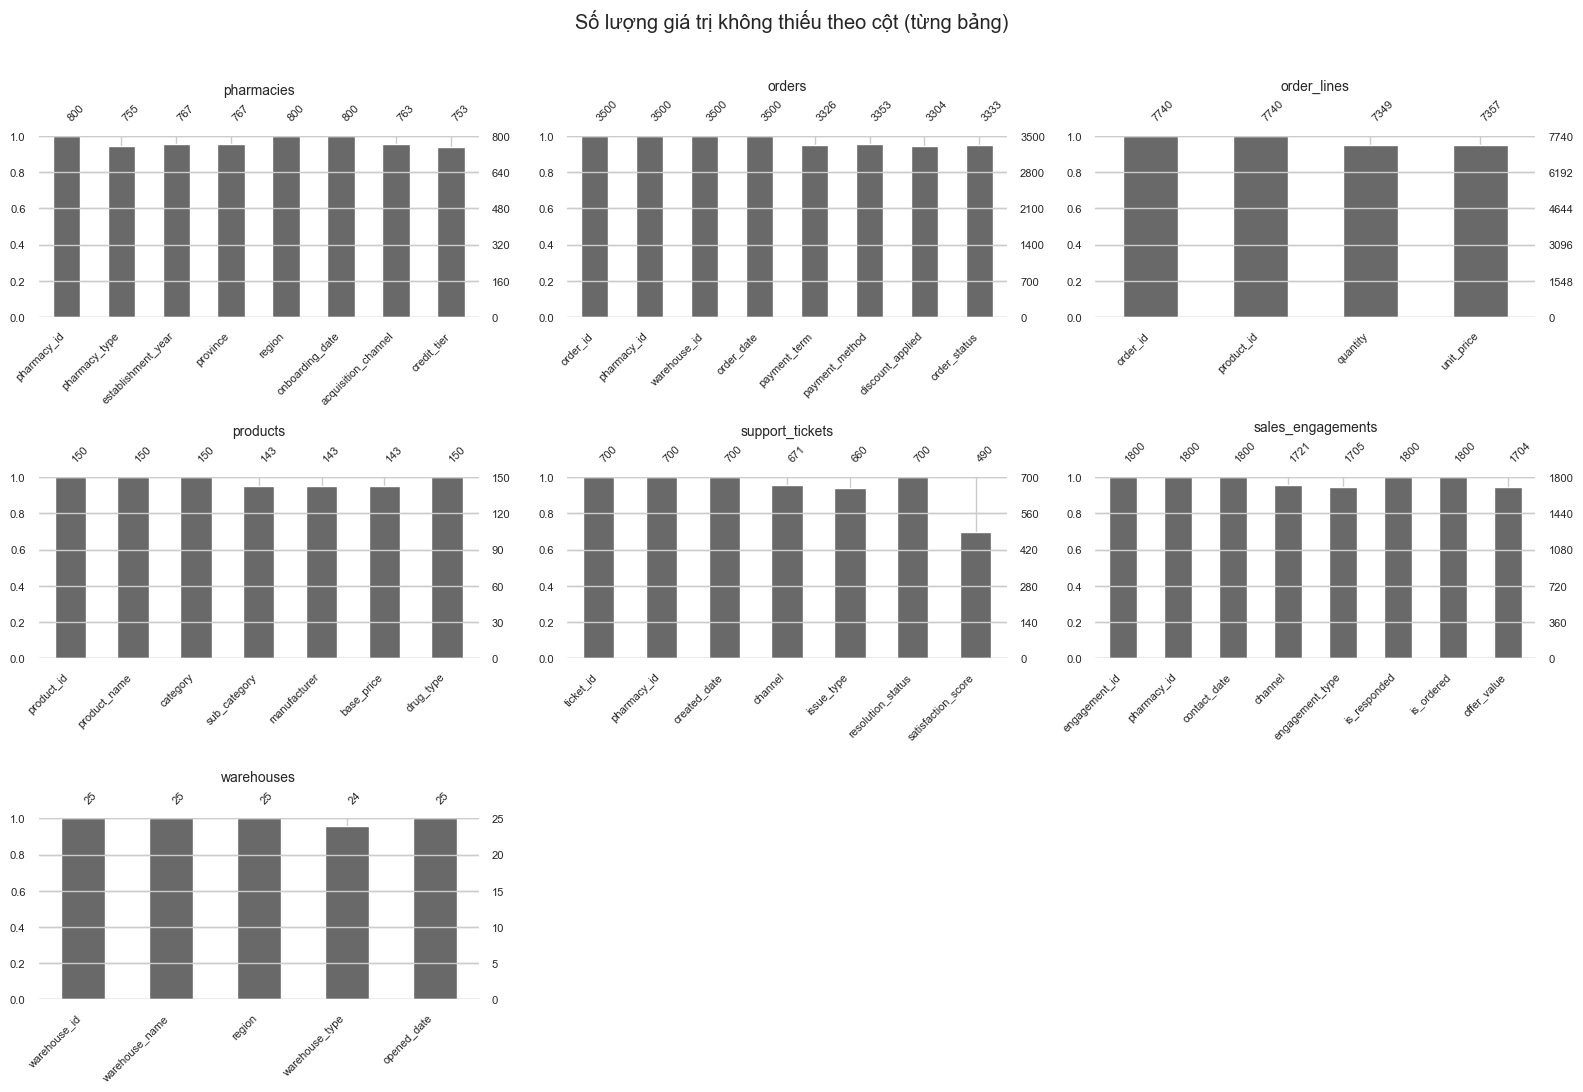

In [6]:
# Biểu đồ số lượng giá trị không thiếu cho TẤT CẢ các bảng (lưới tự động theo số bảng)
fig, axes = make_grid(len(FILES), h=3.6)
for ax, f in zip(axes, FILES):
    msno.bar(data[f], ax=ax, fontsize=8)
    ax.set_title(f, fontsize=10)
for ax in axes[len(FILES):]:
    ax.axis('off')
plt.suptitle('Số lượng giá trị không thiếu theo cột (từng bảng)', y=1.01)
plt.tight_layout(); plt.show()

Ma trận `missingno.matrix` thể hiện vị trí giá trị thiếu theo dòng cho từng bảng: các vạch trắng phân bố rải rác gợi ý việc thiếu mang tính ngẫu nhiên, trong khi các vạch trắng tạo thành dải gợi ý việc thiếu có liên hệ giữa các cột.

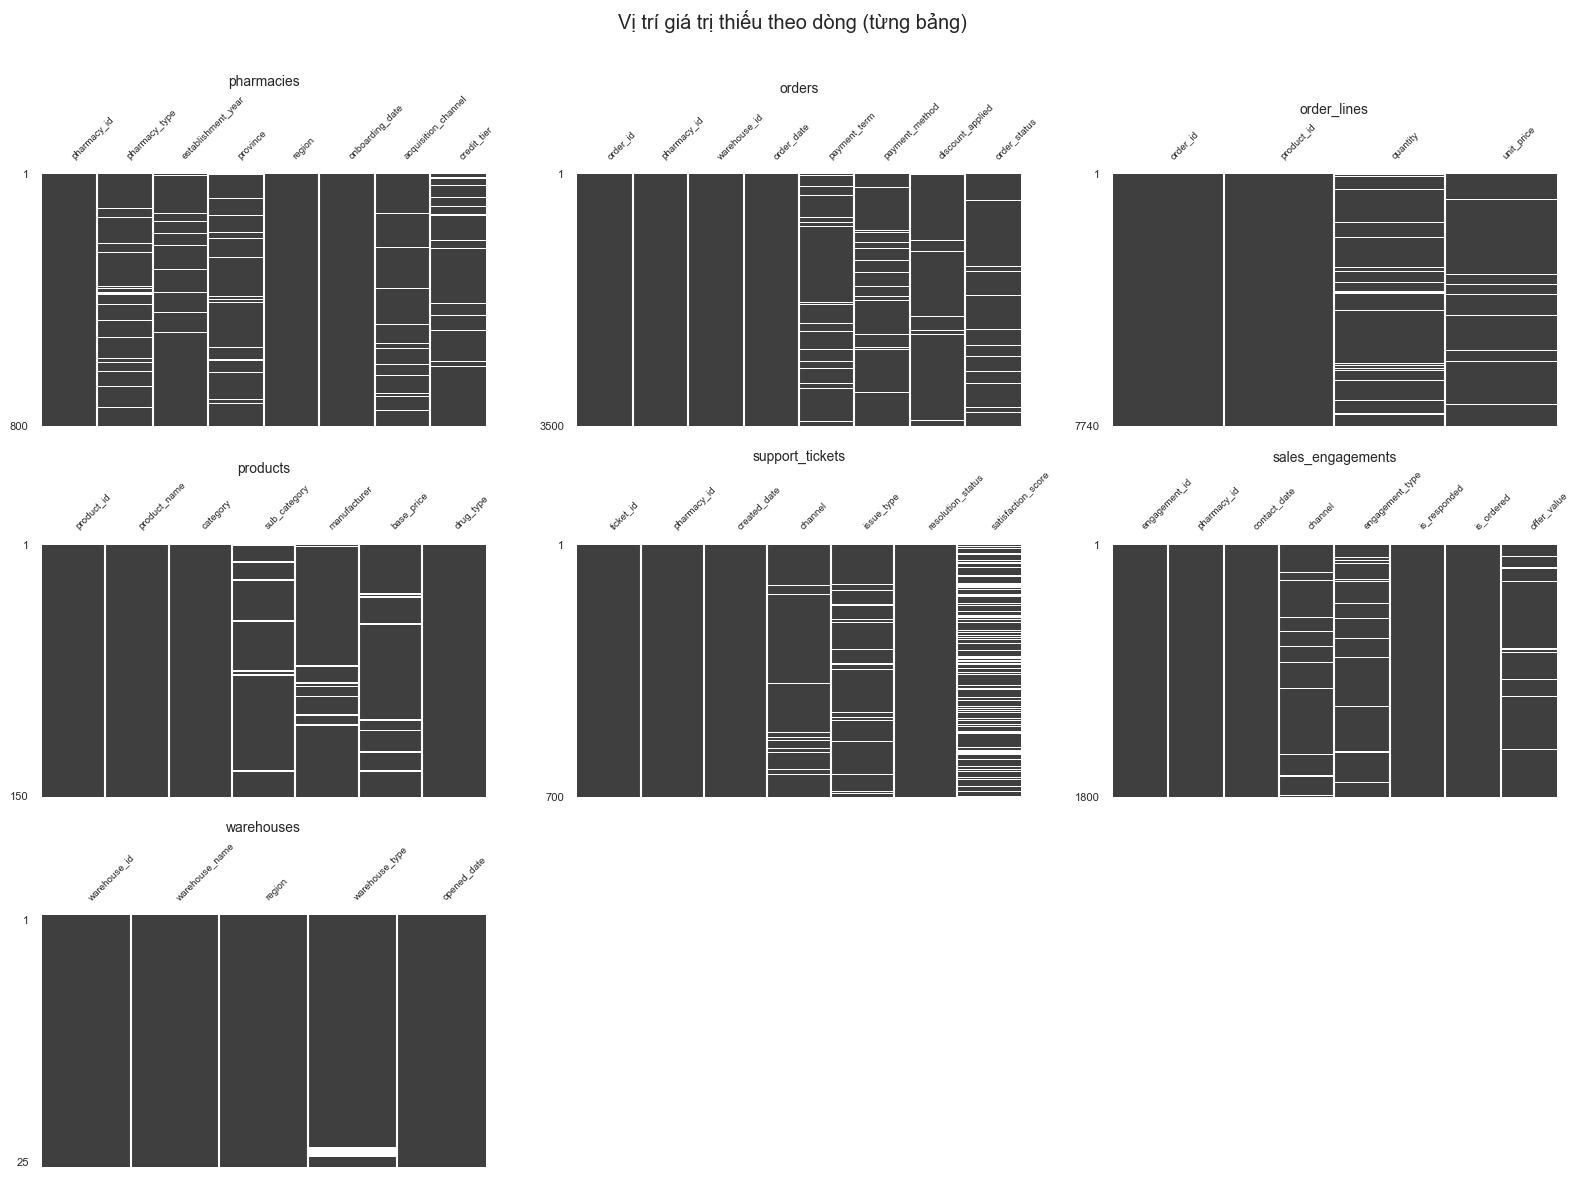

In [7]:
fig, axes = make_grid(len(FILES), h=3.9)
for ax, f in zip(axes, FILES):
    msno.matrix(data[f], ax=ax, fontsize=7, sparkline=False)
    ax.set_title(f, fontsize=10)
for ax in axes[len(FILES):]:
    ax.axis('off')
plt.suptitle('Vị trí giá trị thiếu theo dòng (từng bảng)', y=1.005)
plt.tight_layout(); plt.show()

Ma trận tương quan thiếu (`missingno.heatmap`) đo mức độ hai cột cùng thiếu: giá trị gần **+1** cho thấy hai cột thường thiếu đồng thời (cơ chế MAR/MNAR); giá trị gần **0** cho thấy việc thiếu là độc lập (cơ chế MCAR, có thể điền bằng giá trị đại diện). Chỉ vẽ cho các bảng có từ hai cột thiếu trở lên.

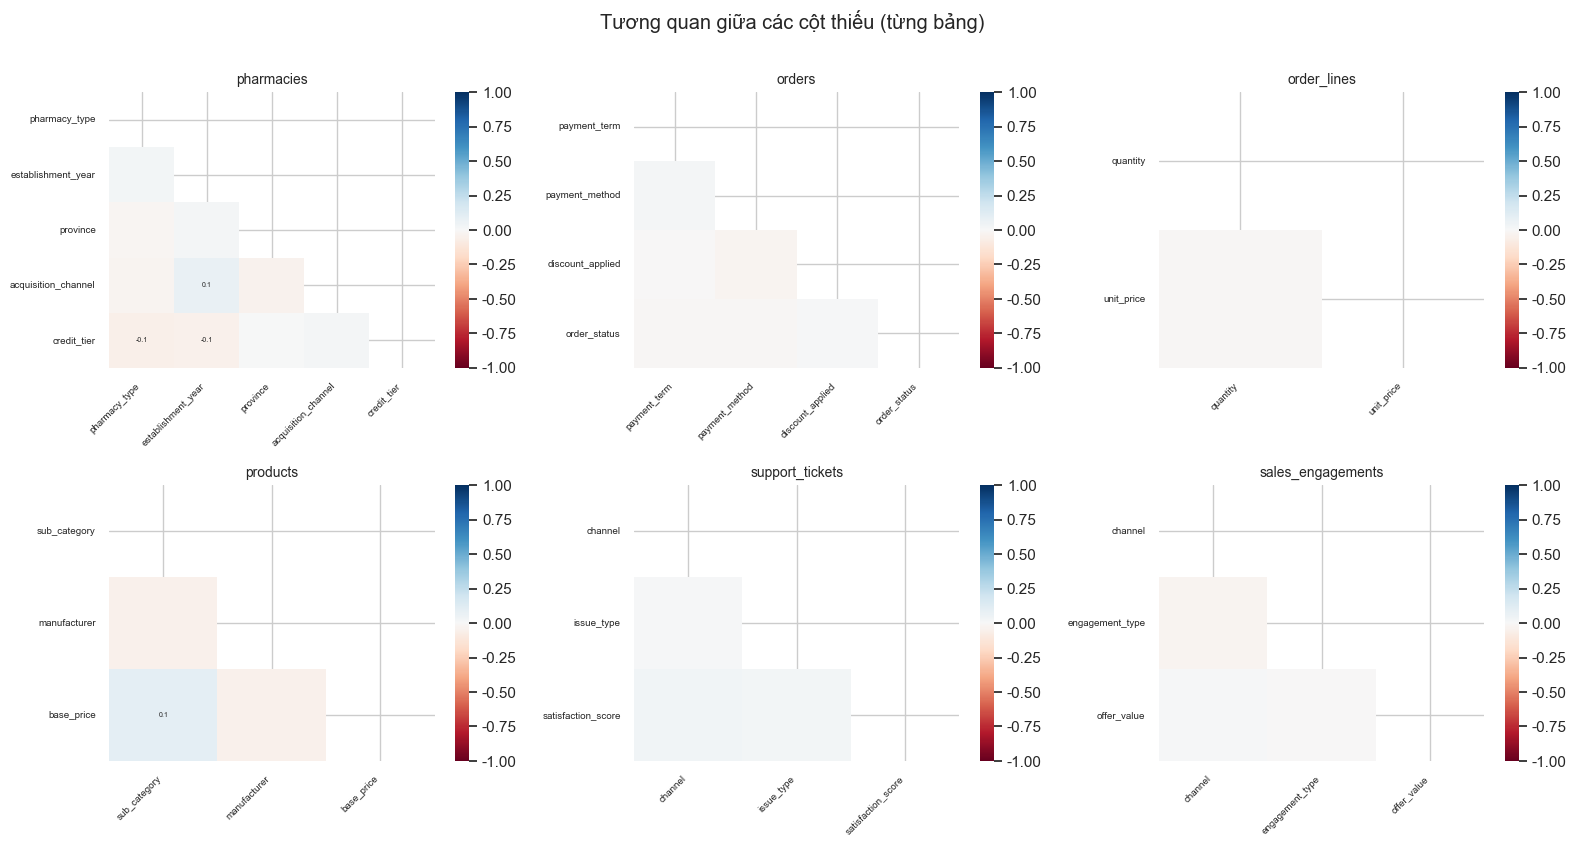

Không vẽ heatmap cho (ít hơn 2 cột thiếu): ['warehouses']


In [8]:
hm_tables = [f for f in FILES if int((data[f].isnull().mean() > 0).sum()) >= 2]
fig, axes = make_grid(len(hm_tables), h=4.2)
for ax, f in zip(axes, hm_tables):
    msno.heatmap(data[f], ax=ax, fontsize=7, cmap='RdBu')
    ax.set_title(f, fontsize=10)
for ax in axes[len(hm_tables):]:
    ax.axis('off')
plt.suptitle('Tương quan giữa các cột thiếu (từng bảng)', y=1.005)
plt.tight_layout(); plt.show()
skipped = [f for f in FILES if f not in hm_tables]
print('Không vẽ heatmap cho (ít hơn 2 cột thiếu):', skipped)

In [9]:
# Bằng chứng định lượng: tương quan thiếu LỚN NHẤT giữa các cột trong mỗi bảng
# (giá trị nhỏ => các cột thiếu độc lập => thiên về cơ chế MCAR)
summary = []
for f in FILES:
    miss = data[f].isnull()
    cols = miss.columns[miss.any()]
    if len(cols) >= 2:
        cm = miss[cols].astype(int).corr().abs().values
        np.fill_diagonal(cm, 0)
        maxc = round(float(np.nanmax(cm)), 3)
    else:
        maxc = None
    summary.append({'bảng': f, 'số cột có thiếu': int(miss.any().sum()),
                    'tương quan thiếu lớn nhất': maxc})
pd.DataFrame(summary)

,bảng,số cột có thiếu,tương quan thiếu lớn nhất
0,pharmacies,5,0.074
1,orders,4,0.026
2,order_lines,2,0.012
3,products,3,0.101
4,support_tickets,3,0.036
5,sales_engagements,3,0.026
6,warehouses,1,NaN


In [10]:
# Riêng support_tickets: kiểm tra thiếu theo GIÁ TRỊ của cột khác (cơ chế cấu trúc)
st = data['support_tickets']
miss_by_status = (st.assign(score_missing=st['satisfaction_score'].isna())
                    .groupby('resolution_status')['score_missing'].mean().round(3))
print('Tỷ lệ thiếu satisfaction_score theo trạng thái xử lý phiếu:')
print((miss_by_status*100).astype(str) + ' %')

Tỷ lệ thiếu satisfaction_score theo trạng thái xử lý phiếu:
resolution_status
Escalated    100.0 %
Pending       85.6 %
Resolved       5.0 %
Name: score_missing, dtype: object


**Kết luận cơ chế thiếu theo từng bảng** (dựa trên ma trận, heatmap và bảng tương quan thiếu lớn nhất ở trên):

| Bảng | Cơ chế thiếu | Bằng chứng | Hướng xử lý |
|---|---|---|---|
| pharmacies | MCAR | tương quan thiếu giữa các cột gần 0; vạch trắng rải rác | điền trung vị (số) / mode (phân loại) |
| orders | MCAR | tương quan thiếu gần 0 | điền mode / xử lý riêng order_status |
| order_lines | MCAR | hai cột quantity, unit_price thiếu độc lập | điền sau khi xử lý giá trị âm |
| products | MCAR | tương quan thiếu gần 0 | điền trung vị / mode |
| support_tickets | **Một phần CẤU TRÚC** | satisfaction_score thiếu theo *giá trị* của resolution_status (Escalated 100%, Pending 85.6%, Resolved 5.0%) — heatmap không bắt được vì đây là phụ thuộc theo giá trị, không phải đồng thời thiếu | **không điền** cho phiếu chưa xử lý xong; chỉ điền ~25 phiếu Resolved thiếu thật |
| sales_engagements | MCAR | tương quan thiếu gần 0 | điền mode / 0 hợp lý |
| warehouses | MCAR | chỉ 1 cột thiếu (4%) | điền mode |

**Lưu ý phương pháp:** `missingno.heatmap` chỉ phát hiện hiện tượng *thiếu đồng thời* giữa các cột. Riêng cơ chế **thiếu theo thiết kế** của `satisfaction_score` (phụ thuộc vào *giá trị* `resolution_status`, một cột không thiếu) phải được phát hiện bằng phép gộp nhóm (`groupby`) như trên, không thể thấy qua heatmap. Đây là dạng thiếu thứ tư, khác MCAR/MAR/MNAR, và **không được điền** vì sẽ tạo thông tin sai lệch.

#### A2. Phân phối các biến số
Sử dụng biểu đồ phân phối (histogram) để quan sát độ lệch (skewness) và biểu đồ hộp (boxplot) để phát hiện giá trị ngoại lai.

Cột số liên tục được vẽ histogram: ['orders.discount_applied', 'order_lines.quantity', 'order_lines.unit_price', 'products.base_price', 'support_tickets.satisfaction_score', 'sales_engagements.offer_value']
Cột số bị loại khỏi nhóm này : ['pharmacies.establishment_year (biến năm -> khảo sát ở A4/A5)', 'sales_engagements.is_ordered (nhị phân -> nhóm phân loại)']


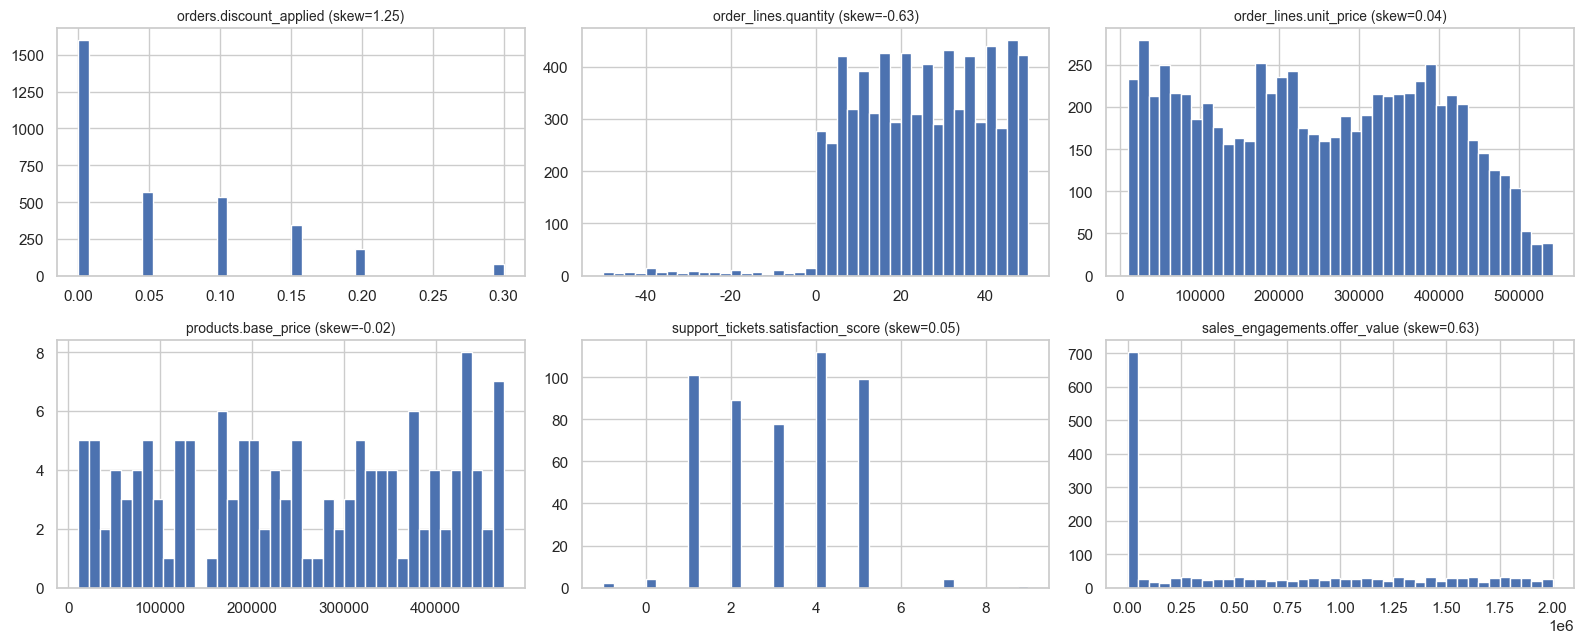

In [11]:
# Tự động chọn TẤT CẢ cột số liên tục trên mọi bảng (loại cờ nhị phân và biến năm),
# in rõ danh sách được vẽ và bị loại để minh bạch — không chọn tay.
num_cols, excluded = [], []
for f in FILES:
    for c in data[f].select_dtypes(include='number').columns:
        nuniq = data[f][c].nunique()
        if nuniq <= 2:
            excluded.append(f'{f}.{c} (nhị phân -> nhóm phân loại)')
        elif c.endswith('year') or c.endswith('_year'):
            excluded.append(f'{f}.{c} (biến năm -> khảo sát ở A4/A5)')
        else:
            num_cols.append((f, c))
print('Cột số liên tục được vẽ histogram:', [f'{f}.{c}' for f, c in num_cols])
print('Cột số bị loại khỏi nhóm này :', excluded)

fig, axes = make_grid(len(num_cols), h=3.3)
for ax, (f, c) in zip(axes, num_cols):
    s = pd.to_numeric(data[f][c], errors='coerce').dropna()
    ax.hist(s, bins=40, color='#4C72B0', edgecolor='white')
    ax.set_title(f'{f}.{c} (skew={s.skew():.2f})', fontsize=10)
for ax in axes[len(num_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

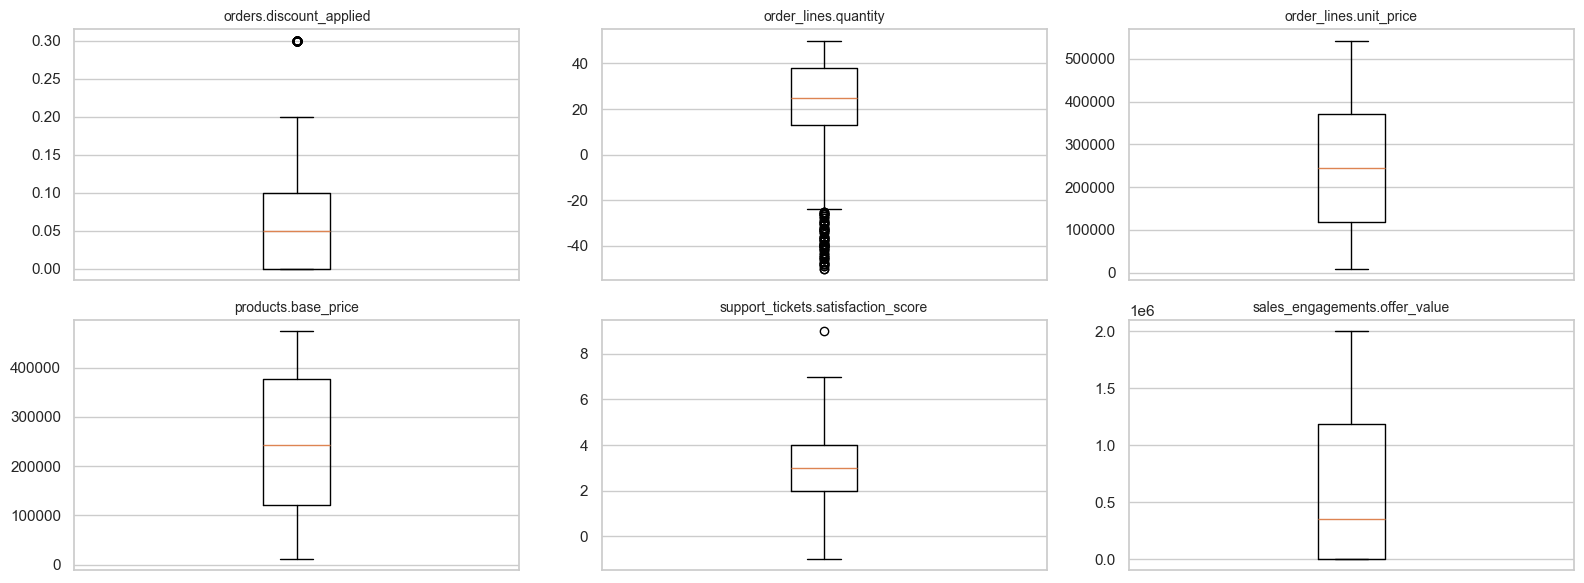

In [12]:
# Biểu đồ hộp cho TẤT CẢ cột số liên tục (cùng danh sách num_cols ở trên) để phát hiện ngoại lai
fig, axes = make_grid(len(num_cols), h=3.0)
for ax, (f, c) in zip(axes, num_cols):
    s = pd.to_numeric(data[f][c], errors='coerce').dropna()
    ax.boxplot(s, vert=True); ax.set_title(f'{f}.{c}', fontsize=10); ax.set_xticks([])
for ax in axes[len(num_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

In [13]:
# Bảng tóm tắt phân phối các biến số: độ lệch, tỷ lệ giá trị 0/âm, số mức, ngoại lai IQR
rows = []
for f, c in num_cols:
    s = pd.to_numeric(data[f][c], errors='coerce').dropna()
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3 - q1
    out = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())
    rows.append({'cột': f'{f}.{c}', 'skew': round(s.skew(), 2),
                 '% bằng 0': round((s == 0).mean()*100), '% âm': round((s < 0).mean()*100, 1),
                 'số mức': int(s.nunique()), 'ngoại lai IQR': out})
pd.DataFrame(rows)

,cột,skew,% bằng 0,% âm,số mức,ngoại lai IQR
0,orders.discount_applied,1.25,48,0.0,6,77
1,order_lines.quantity,-0.63,0,2.1,100,82
2,order_lines.unit_price,0.04,0,0.0,3861,0
3,products.base_price,-0.02,0,0.0,141,0
4,support_tickets.satisfaction_score,0.05,1,0.4,9,1
5,sales_engagements.offer_value,0.63,40,0.0,783,0


**Kết luận từ phân phối các biến số:**
- **Biến gần đối xứng, không ngoại lai** (`unit_price` skew ≈ 0.04; `base_price` skew ≈ −0.02): có thể điền khuyết bằng trung bình, không cần biến đổi.
- **Biến rời rạc hoặc tập trung nhiều giá trị 0** (`discount_applied` chỉ 6 mức, 48% bằng 0; `offer_value` skew 0.63, 40% bằng 0): bản chất là biến rời rạc / tập trung tại 0 — giá trị 0 mang ý nghĩa "không giảm giá / không khuyến mãi", nên điền khuyết bằng trung vị hoặc 0 và cân nhắc biến đổi log, không xem là biến liên tục thuần.
- **Biến chứa lỗi dữ liệu** (`quantity` có 2.1% giá trị âm, nhỏ nhất −50; `satisfaction_score` có giá trị −1 ngoài thang 1–9): cần xử lý ở Bước 2 trước khi sử dụng.
- Tỷ lệ ngoại lai theo IQR đều thấp (≤ 2.3%) và chủ yếu là lỗi nhập (giá trị âm), không phải giá trị cực đoan hợp lệ.

→ **Định hướng cho Bước 2–3:** cột lệch hoặc nhiều ngoại lai dùng trung vị để điền và chuẩn hóa bền (robust) / log; cột đối xứng có thể dùng trung bình.

#### A3. Phân phối các biến phân loại
Khảo sát tần suất của toàn bộ các biến phân loại trên từng bảng.

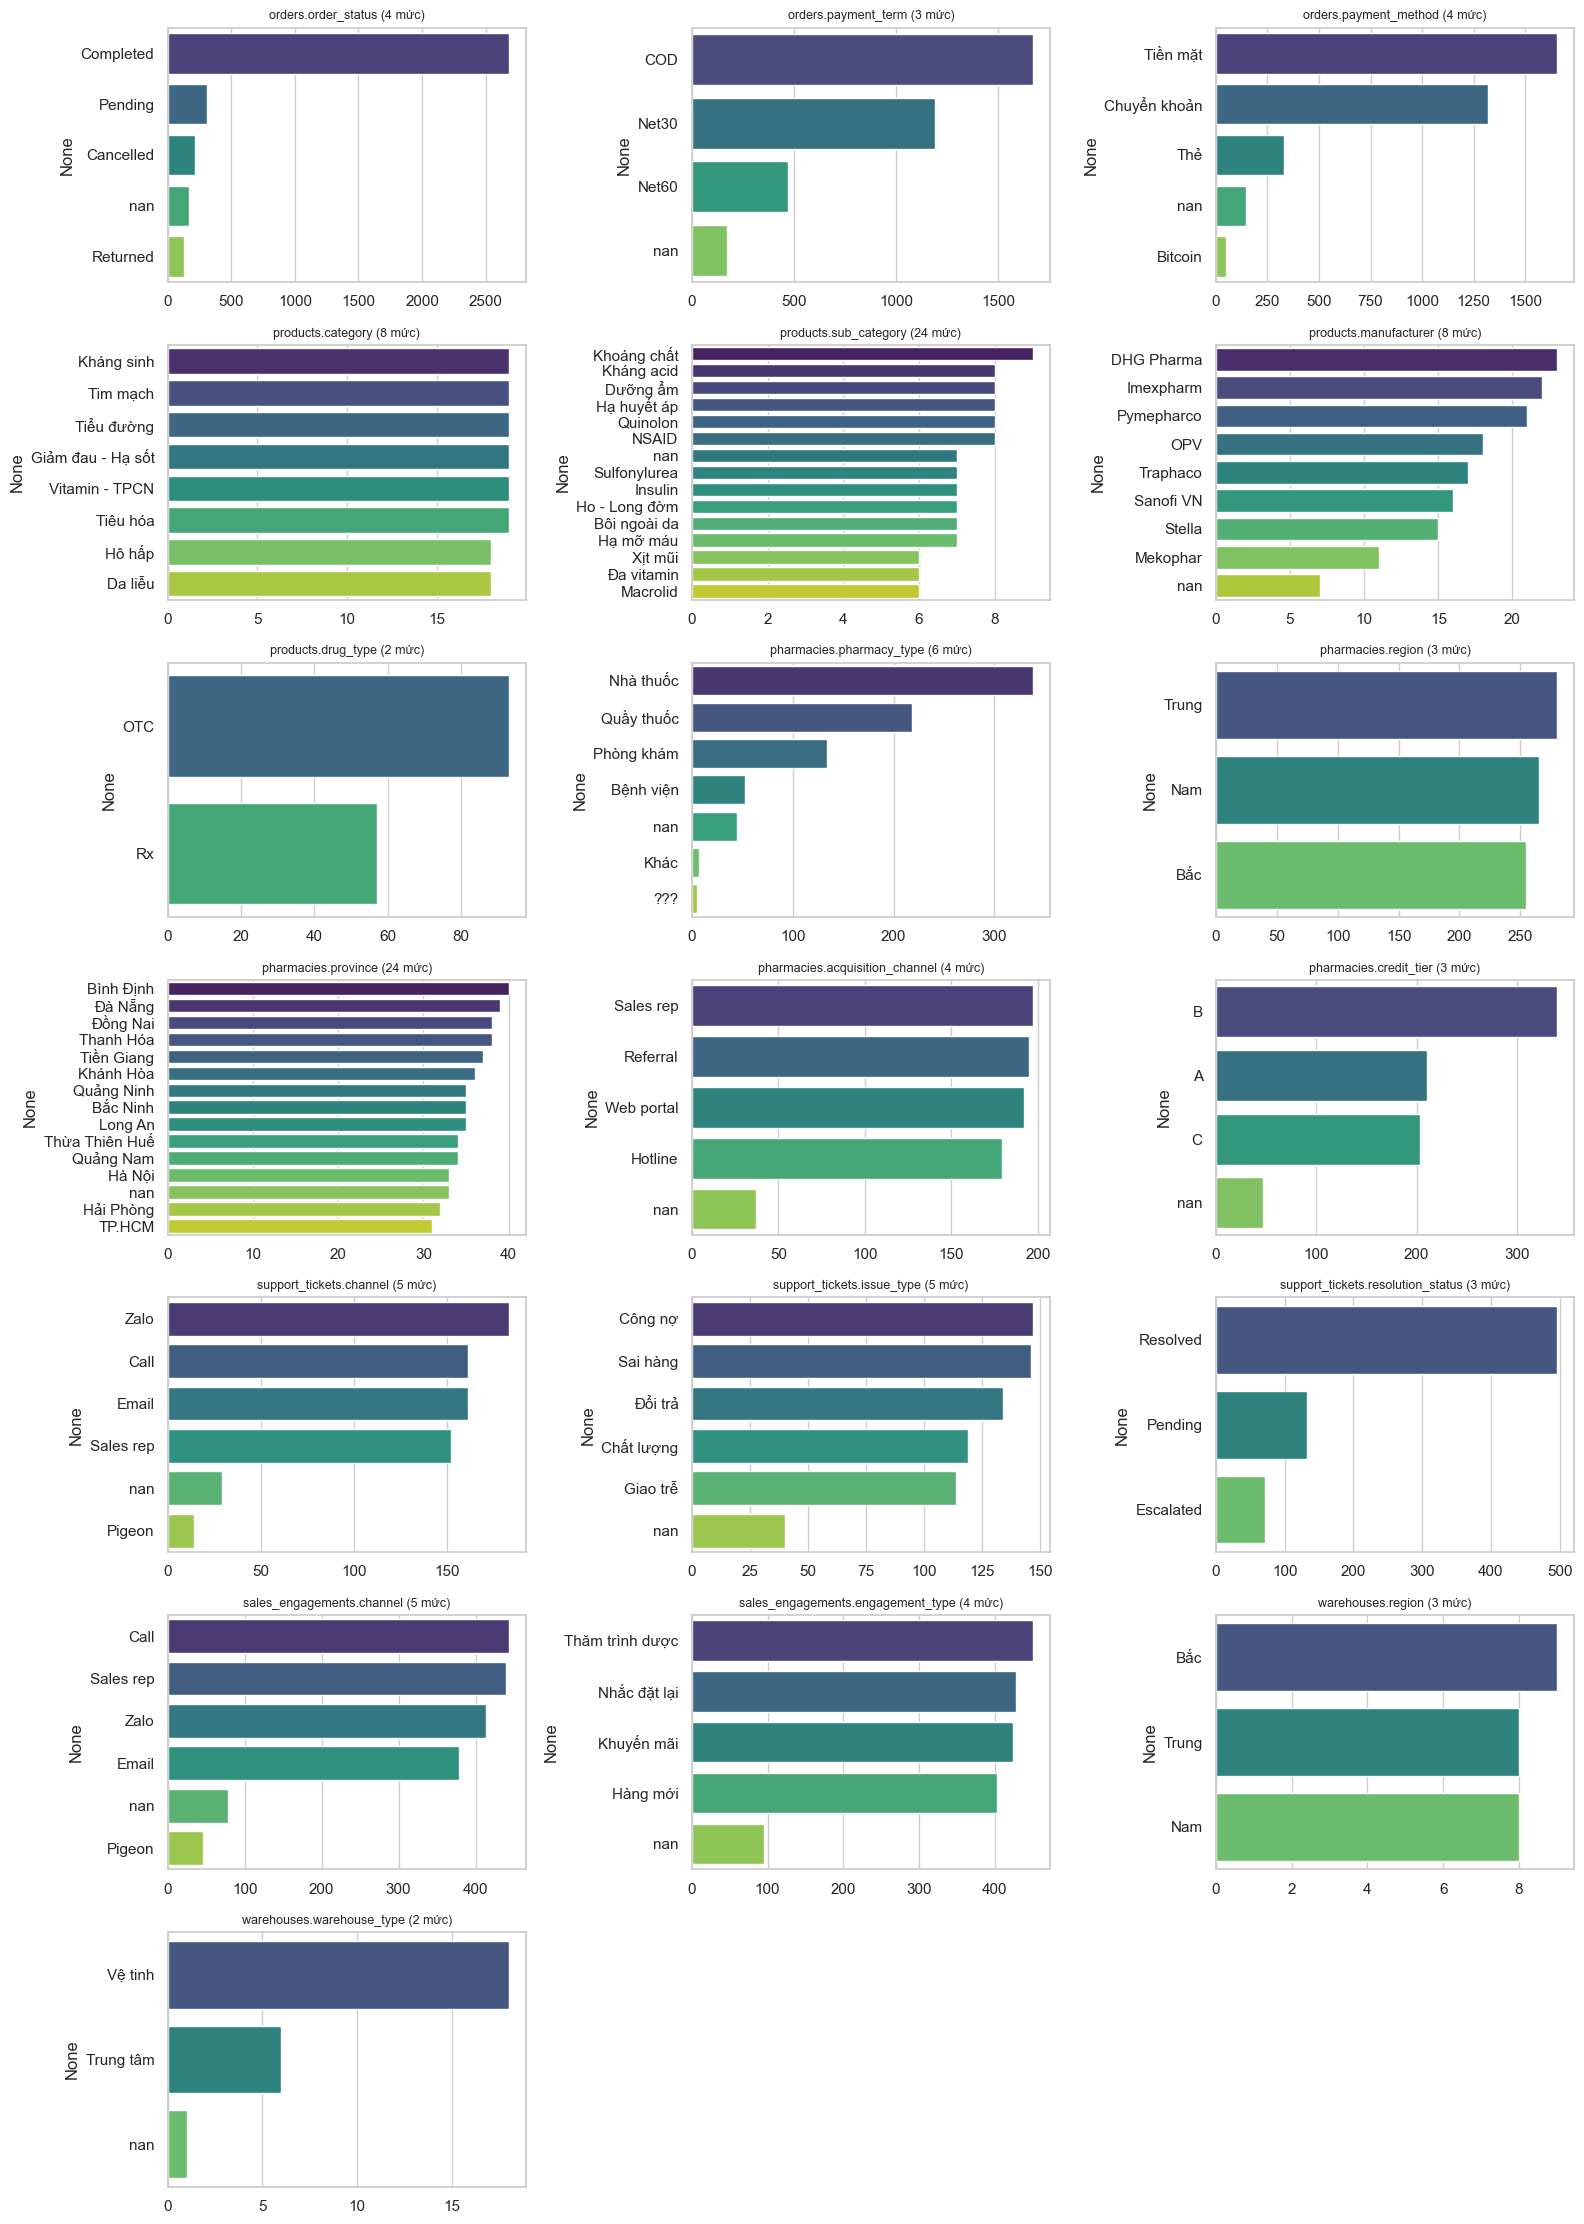

In [14]:
CAT_COLS = [
    ('orders','order_status'),('orders','payment_term'),('orders','payment_method'),
    ('products','category'),('products','sub_category'),('products','manufacturer'),('products','drug_type'),
    ('pharmacies','pharmacy_type'),('pharmacies','region'),('pharmacies','province'),
    ('pharmacies','acquisition_channel'),('pharmacies','credit_tier'),
    ('support_tickets','channel'),('support_tickets','issue_type'),('support_tickets','resolution_status'),
    ('sales_engagements','channel'),('sales_engagements','engagement_type'),
    ('warehouses','region'),('warehouses','warehouse_type'),
]
fig, axes = make_grid(len(CAT_COLS), h=3.2)
for ax, (f, c) in zip(axes, CAT_COLS):
    vc = data[f][c].value_counts(dropna=False).head(15)
    vc.index = [str(i) for i in vc.index]
    sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis')
    ax.set_title(f'{f}.{c} ({data[f][c].nunique()} mức)', fontsize=9); ax.set_xlabel('')
for ax in axes[len(CAT_COLS):]: ax.axis('off')
plt.tight_layout(); plt.show()

In [15]:
# Cột is_responded là biến nhị phân nhưng được biểu diễn không đồng nhất
print('sales_engagements.is_responded — các giá trị nguyên thủy:')
print(data['sales_engagements']['is_responded'].value_counts(dropna=False))

sales_engagements.is_responded — các giá trị nguyên thủy:
is_responded
1       939
0       803
Yes      31
TRUE     27
Name: count, dtype: int64


**Nhận xét:** cột `is_responded` lẽ ra là biến nhị phân (0/1) nhưng được biểu diễn lẫn lộn nhiều dạng (`'1'`, `'0'`, `'Yes'`, `'TRUE'`). Cần quy chuẩn về {0, 1} ở bước làm sạch trước khi sử dụng.

In [16]:
# Bảng tóm tắt các biến phân loại: số mức (cardinality) và tỷ trọng nhóm phổ biến nhất
rows = []
for f, c in CAT_COLS:
    vc = data[f][c].value_counts(normalize=True)
    rows.append({'cột': f'{f}.{c}', 'số mức': int(data[f][c].nunique()),
                 'nhóm phổ biến nhất': str(vc.index[0]), 'tỷ trọng %': round(vc.iloc[0]*100)})
pd.DataFrame(rows).sort_values('số mức', ascending=False).reset_index(drop=True)

,cột,số mức,nhóm phổ biến nhất,tỷ trọng %
0,products.sub_category,24,Khoáng chất,6
1,pharmacies.province,24,Bình Định,5
2,products.manufacturer,8,DHG Pharma,16
3,products.category,8,Kháng sinh,13
4,pharmacies.pharmacy_type,6,Nhà thuốc,45
5,support_tickets.issue_type,5,Công nợ,22
6,sales_engagements.channel,5,Call,26
7,support_tickets.channel,5,Zalo,27
8,pharmacies.acquisition_channel,4,Sales rep,26
9,orders.order_status,4,Completed,80


**Kết luận từ phân phối các biến phân loại:**
- **Biến có số mức cao (high-cardinality), phân bố phẳng:** `province` (24 tỉnh, nhóm lớn nhất chỉ 5%) và `sub_category` (24 nhóm, lớn nhất 6%). Mã hóa one-hot sẽ tạo rất nhiều cột thưa; kết hợp mô hình tuyến tính và phân chia theo thời gian dễ phát sinh tình trạng một mức chỉ xuất hiện ở một tập. **Định hướng (Bước 3):** ưu tiên dùng `region` (3 mức) thay cho `province`; gộp các nhóm hiếm của `sub_category` và `manufacturer`.
- **Biến có một nhóm áp đảo:** `order_status` (Completed khoảng 77% tổng đơn), `drug_type` (OTC 62%), `resolution_status` (Resolved 71%, tức khoảng 29% phiếu chưa đóng — phù hợp với phần thiếu mang tính cấu trúc của `satisfaction_score`), `warehouse_type` (Vệ tinh 75%).
- **Biến phân bố tương đối đều** (`region`, `credit_tier`, `payment_term`, các kênh liên hệ): phù hợp mã hóa one-hot trực tiếp.

→ **Định hướng cho Bước 2.5–3:** dùng one-hot cho biến ít mức; gộp hoặc thay thế cho biến nhiều mức; cột `order_status` được dùng để lọc đơn hợp lệ.

#### A4. Biến thời gian
Đây là nhóm biến quan trọng do đề bài yêu cầu phân chia dữ liệu theo thời gian. Cần kiểm tra định dạng ngày, bởi cùng một cột có thể chứa nhiều định dạng khác nhau.

In [17]:
def sniff_date_format(series):
    out = {}
    for v in series.dropna().astype(str):
        if re.match(r'^\d{4}-\d{2}-\d{2}$', v):       k='YYYY-MM-DD'
        elif re.match(r'^\d{1,2}/\d{1,2}/\d{4}$', v):  k='DD/MM/YYYY'
        elif re.match(r'^\d{1,2}-\d{1,2}-\d{4}$', v):  k='MM-DD-YYYY'
        else:                                          k='Khác'
        out[k] = out.get(k,0)+1
    return out

date_cols = {'orders':'order_date','pharmacies':'onboarding_date',
             'support_tickets':'created_date','sales_engagements':'contact_date','warehouses':'opened_date'}
for f,c in date_cols.items():
    print(f'{f}.{c:16s} -> {sniff_date_format(data[f][c])}')

orders.order_date       -> {'YYYY-MM-DD': 2806, 'DD/MM/YYYY': 425, 'MM-DD-YYYY': 269}
pharmacies.onboarding_date  -> {'DD/MM/YYYY': 90, 'YYYY-MM-DD': 648, 'MM-DD-YYYY': 62}
support_tickets.created_date     -> {'YYYY-MM-DD': 559, 'DD/MM/YYYY': 81, 'MM-DD-YYYY': 60}
sales_engagements.contact_date     -> {'MM-DD-YYYY': 143, 'YYYY-MM-DD': 1428, 'DD/MM/YYYY': 229}
warehouses.opened_date      -> {'YYYY-MM-DD': 23, 'DD/MM/YYYY': 2}


In [18]:
def parse_mixed_date(series):
    '''Phân tích ngày đa định dạng: dấu "/" theo %d/%m/%Y, dấu "-" theo %m-%d-%Y.
    Hai định dạng dùng dấu phân tách khác nhau nên không gây nhầm lẫn ngày/tháng.'''
    s = series.astype(str).str.strip()
    o = pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
    m = o.isna(); o[m] = pd.to_datetime(s[m], format='%d/%m/%Y', errors='coerce')
    m = o.isna(); o[m] = pd.to_datetime(s[m], format='%m-%d-%Y', errors='coerce')
    return o

print('Khoảng thời gian sau khi chuẩn hóa (giá trị lớn nhất phản ánh cửa sổ dữ liệu):')
for f,c in date_cols.items():
    d = parse_mixed_date(data[f][c])
    print(f'  {f}.{c:16s}: {d.min().date()} đến {d.max().date()}  | không phân tích được: {d.isna().sum()}')

Khoảng thời gian sau khi chuẩn hóa (giá trị lớn nhất phản ánh cửa sổ dữ liệu):
  orders.order_date      : 2020-01-22 đến 2025-12-31  | không phân tích được: 0
  pharmacies.onboarding_date : 2020-01-01 đến 2025-06-28  | không phân tích được: 0
  support_tickets.created_date    : 2020-03-17 đến 2025-12-31  | không phân tích được: 0
  sales_engagements.contact_date    : 2020-01-08 đến 2025-12-31  | không phân tích được: 0
  warehouses.opened_date     : 2015-01-21 đến 2022-11-14  | không phân tích được: 0


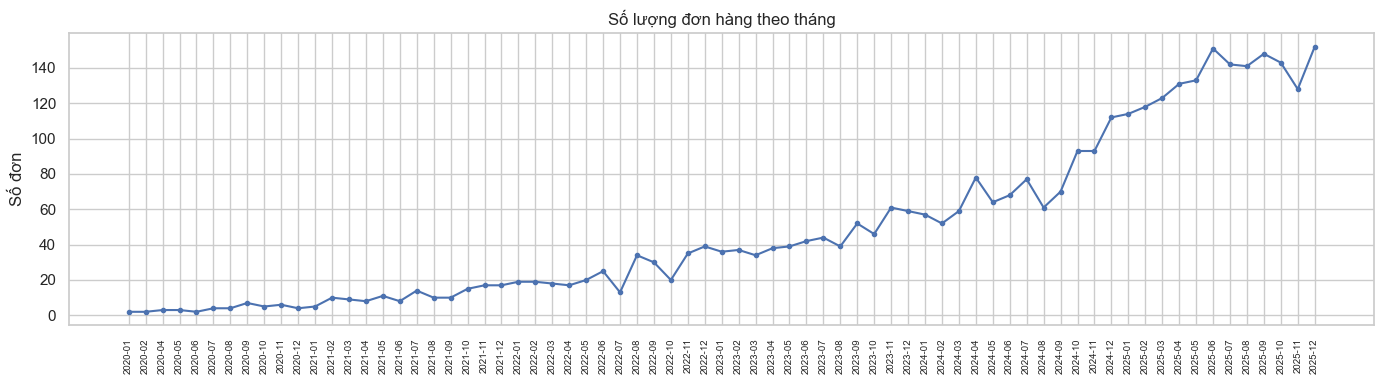

In [19]:
od_dates = parse_mixed_date(data['orders']['order_date']).dropna()
monthly = od_dates.dt.to_period('M').value_counts().sort_index()
monthly.index = monthly.index.astype(str)
plt.figure(figsize=(14, 4))
plt.plot(monthly.index, monthly.values, marker='o', ms=3)
plt.xticks(rotation=90, fontsize=7); plt.title('Số lượng đơn hàng theo tháng')
plt.ylabel('Số đơn'); plt.tight_layout(); plt.show()

In [20]:
# Kiểm tra ràng buộc logic của biến thời gian sau khi chuẩn hóa
ph = data['pharmacies'].copy(); od = data['orders'].copy()
ph['onb'] = parse_mixed_date(ph['onboarding_date'])
ph['est'] = pd.to_numeric(ph['establishment_year'], errors='coerce')
od['d']   = parse_mixed_date(od['order_date'])
mg = od.merge(ph[['pharmacy_id','onb']], on='pharmacy_id', how='left')

checks = [
    ['Đơn hàng phát sinh trước ngày onboarding', int((mg['d'] < mg['onb']).sum())],
    ['Đơn hàng có ngày trong tương lai', int((od['d'] > REF_DATE).sum())],
    ['Năm thành lập sau năm onboarding (không hợp lệ)',
        int((ph.loc[ph['onb'].notna()&ph['est'].notna(),'est']
             > ph.loc[ph['onb'].notna()&ph['est'].notna(),'onb'].dt.year).sum())],
]
pd.DataFrame(checks, columns=['Ràng buộc logic của biến thời gian', 'Số dòng vi phạm'])

,Ràng buộc logic của biến thời gian,Số dòng vi phạm
0,Đơn hàng phát sinh trước ngày onboarding,0
1,Đơn hàng có ngày trong tương lai,0
2,Năm thành lập sau năm onboarding (không hợp lệ),3


**Kết luận về biến thời gian:**
- Mỗi cột ngày chứa đồng thời ba định dạng (`YYYY-MM-DD` chiếm đa số, cùng `DD/MM/YYYY` và `MM-DD-YYYY`); hàm `parse_mixed_date()` chuẩn hóa được toàn bộ, không còn giá trị không phân tích được.
- Dữ liệu trải dài từ năm 2020 đến hết **2025-12-31** ở cả ba bảng có yếu tố thời gian (orders, support_tickets, sales_engagements). Mốc kết thúc chung này xác định **cửa sổ rò rỉ thời gian**: khi xây dựng nhãn và đặc trưng cần cắt theo mốc T trên *mọi* bảng, không riêng orders.
- Kiểm tra ràng buộc logic: không có đơn hàng phát sinh trước ngày onboarding hay đơn hàng trong tương lai; tồn tại 3 dòng có năm thành lập (2030, 2099) sau năm onboarding — các giá trị này đồng thời nằm ngoài khoảng năm hợp lệ, nên được xử lý chung ở Bước 2.

#### A5. Giá trị ngoại lai và ràng buộc miền giá trị
Ngoài ngoại lai theo nghĩa thống kê (IQR), cần kiểm tra **ràng buộc miền giá trị theo ngữ nghĩa**. Hai loại này khác nhau: ví dụ giá trị `establishment_year = 2099` vẫn nằm trong khoảng phổ biến (IQR không phát hiện) nhưng vô lý về mặt logic — đây thực chất là giá trị thiếu được (disguised-missing). Do đó sử dụng biên động `[1900, năm hiện tại]` kết hợp ràng buộc theo ngày onboarding.

In [21]:
REF_YEAR = REF_DATE.year
rows = []
ol = data['order_lines']
q = pd.to_numeric(ol['quantity'], errors='coerce')
rows.append(['order_lines.quantity','Số lượng âm',int((q<0).sum()),f'min={q.min()}'])
up = pd.to_numeric(ol['unit_price'], errors='coerce')
rows.append(['order_lines.unit_price','Giá trị âm',int((up<0).sum()),f'min={up.min()}'])
sat = pd.to_numeric(data['support_tickets']['satisfaction_score'], errors='coerce')
rows.append(['support_tickets.satisfaction_score','Ngoài thang 1-5',int((sat.notna() & ~sat.between(1,5)).sum()),f'min={sat.min()}, max={sat.max()}, các giá trị lạ: -1,0,7,9'])
ey = pd.to_numeric(data['pharmacies']['establishment_year'], errors='coerce')
rows.append(['pharmacies.establishment_year',f'Ngoài khoảng [1900, {REF_YEAR}]',int(((ey<1900)|(ey>REF_YEAR)).sum()),f'min={ey.min()}, max={ey.max()}'])
disc = pd.to_numeric(data['orders']['discount_applied'], errors='coerce')
rows.append(['orders.discount_applied','Ngoài khoảng [0, 1]',int(((disc<0)|(disc>1)).sum()),f'min={disc.min()}, max={disc.max()}'])
pd.DataFrame(rows, columns=['Cột','Loại vi phạm','Số dòng','Chi tiết'])

,Cột,Loại vi phạm,Số dòng,Chi tiết
0,order_lines.quantity,Số lượng âm,157,min=-50.0
1,order_lines.unit_price,Giá trị âm,0,min=9600.0
2,support_tickets.satisfaction_score,Ngoài thang 1-5,11,"min=-1.0, max=9.0, các giá trị lạ: -1,0,7,9"
3,pharmacies.establishment_year,"Ngoài khoảng [1900, 2026]",7,"min=1800.0, max=2099.0"
4,orders.discount_applied,"Ngoài khoảng [0, 1]",0,"min=0.0, max=0.3"


**Kết luận về ngoại lai và miền giá trị:** phát hiện các vi phạm cần xử lý ở Bước 2 — `quantity` có 157 giá trị âm (lỗi nhập). Cột `satisfaction_score` có **thang hợp lệ 1–5** (khối chính khoảng 479 phiếu dồn ở 1–5, sau đó rớt hẳn); các giá trị **−1, 0, 7, 9** (tổng 11 dòng) nằm ngoài thang, là nhiễu cần loại. Cột `establishment_year` có giá trị ngoài khoảng hợp lệ (như 1800, 2030, 2099 — disguised-missing (giá trị thiếu, (disguised-missing))). Các cột `unit_price`, `base_price`, `discount_applied` đều nằm trong miền hợp lệ.

#### A6. Kiểm tra ràng buộc logic
Đề bài nêu rõ một số ràng buộc logic cần kiểm tra giữa các cột.

In [22]:
se = data['sales_engagements'].copy()
resp_map = {'1':1,'0':0,'Yes':1,'TRUE':1,'True':1,'No':0,'FALSE':0}
se['resp_norm'] = se['is_responded'].astype(str).map(resp_map)
print(f'[1] is_ordered = 1 nhưng is_responded = 0 (đặt hàng khi chưa phản hồi): {((se["is_ordered"]==1)&(se["resp_norm"]==0)).sum()} dòng')

st = data['support_tickets']; sat = pd.to_numeric(st['satisfaction_score'], errors='coerce')
open_mask = st['resolution_status'].isin(['Pending','Escalated'])
print(f'[2] Phiếu Pending/Escalated nhưng có điểm hài lòng (không hợp lệ): {(open_mask & sat.notna()).sum()} dòng')
print(f'[3] Phiếu Resolved nhưng thiếu điểm hài lòng (thiếu thực sự): {(~open_mask & sat.isna()).sum()} dòng')

[1] is_ordered = 1 nhưng is_responded = 0 (đặt hàng khi chưa phản hồi): 41 dòng
[2] Phiếu Pending/Escalated nhưng có điểm hài lòng (không hợp lệ): 19 dòng
[3] Phiếu Resolved nhưng thiếu điểm hài lòng (thiếu thực sự): 25 dòng


**Kết luận về ràng buộc logic:** dữ liệu có một số mâu thuẫn nội tại cần hiệu chỉnh ở Bước 2 — 41 bản ghi đặt hàng khi chưa phản hồi (`is_ordered = 1` nhưng `is_responded = 0`), và 19 phiếu chưa xử lý xong nhưng đã có điểm hài lòng. Riêng 25 phiếu `Resolved` thiếu điểm là giá trị thiếu thực sự, khác với phần thiếu mang tính cấu trúc đã phân tích ở mục A1.

#### A7. Trùng lặp, khóa và tính nhất quán
Kiểm tra bản ghi trùng lặp (toàn dòng và theo khóa tổ hợp), khoảng trắng thừa trong biến phân loại, và tính nhất quán của giá trị giữa các bảng.

In [23]:
ol = data['order_lines']
print('Số bản ghi trùng lặp toàn dòng:')
for f in FILES:
    print(f'  {f:18s}: {data[f].duplicated().sum()}')
print(f'order_lines — trùng theo khóa tổ hợp (order_id, product_id): {ol.duplicated(["order_id","product_id"]).sum()}')

ws = 0
for f, c in CAT_COLS:
    s = data[f][c].dropna().astype(str)
    ws += int((s != s.str.strip()).sum())
print(f'Tổng số giá trị phân loại có khoảng trắng thừa: {ws} (giá trị 0 nghĩa là không có)')

print('Giá trị region trong pharmacies:', sorted(data['pharmacies']['region'].dropna().unique()))
print('Giá trị region trong warehouses:', sorted(data['warehouses']['region'].dropna().unique()))

Số bản ghi trùng lặp toàn dòng:
  pharmacies        : 0
  orders            : 0
  order_lines       : 0
  products          : 0
  support_tickets   : 0
  sales_engagements : 0
  warehouses        : 0
order_lines — trùng theo khóa tổ hợp (order_id, product_id): 0
Tổng số giá trị phân loại có khoảng trắng thừa: 0 (giá trị 0 nghĩa là không có)
Giá trị region trong pharmacies: ['Bắc', 'Nam', 'Trung']
Giá trị region trong warehouses: ['Bắc', 'Nam', 'Trung']


**Kết luận về trùng lặp và nhất quán:** không có bản ghi trùng toàn dòng hay trùng theo khóa tổ hợp, không có khoảng trắng thừa trong biến phân loại, và giá trị `region` nhất quán giữa hai bảng pharmacies và warehouses. Các trục chất lượng dữ liệu này đạt yêu cầu, không cần xử lý thêm.

### 4.3. Sơ đồ quan hệ thực thể (ERD) và khóa nối

```mermaid
erDiagram
    pharmacies        ||--o{ orders            : "places (1-n)"
    warehouses        ||--o{ orders            : "fulfilled at (1-n)"
    orders            ||--|{ order_lines       : "contains (1-n)"
    products          ||--o{ order_lines       : "belongs to (1-n)"
    pharmacies        ||--o{ support_tickets   : "creates (1-n)"
    pharmacies        ||--o{ sales_engagements : "engaged (1-n)"

    pharmacies {
        string pharmacy_id PK
        int    n_rows "800"
    }
    warehouses {
        string warehouse_id PK
        int    n_rows "25"
    }
    orders {
        string order_id PK
        string pharmacy_id FK
        string warehouse_id FK
        int    n_rows "3500"
    }
    order_lines {
        string order_id FK
        string product_id FK
        int    n_rows "7740"
    }
    products {
        string product_id PK
        int    n_rows "150"
    }
    support_tickets {
        string ticket_id PK
        string pharmacy_id FK
        int    n_rows "700"
    }
    sales_engagements {
        string engagement_id PK
        string pharmacy_id FK
        int    n_rows "1800"
    }
```

**Quan hệ giữa các bảng (bản số):**
- `pharmacies (1) — orders (n)`; `orders (n) — warehouses (1)`
- `orders (1) — order_lines (n)`; `order_lines (n) — products (1)`
- `pharmacies (1) — support_tickets (n)`; `pharmacies (1) — sales_engagements (n)`

Grain mục tiêu là **một dòng tương ứng một nhà thuốc** (ảnh chụp tại mốc thời gian T). Do đó các bảng con (orders, support_tickets, sales_engagements) cần được tổng hợp về mức nhà thuốc trước khi nối (thực hiện ở Bước 2.5).

#### Chiến lược nối bảng (LEFT JOIN và INNER JOIN)
Nguyên tắc: dùng **LEFT JOIN** khi cần giữ toàn bộ bản ghi của bảng gốc (kể cả bản ghi không khớp); dùng **INNER JOIN** khi chỉ giữ các bản ghi khớp ở cả hai bảng.

| Phép nối | Loại | Lý do lựa chọn |
|---|---|---|
| `order_lines` → `products` | LEFT | Giữ mọi dòng chi tiết đơn để tính `total_amount` |
| `order_lines` → `orders` | INNER | Mỗi dòng chi tiết phải thuộc một đơn hàng hợp lệ |
| `orders` → `warehouses` | LEFT | Giữ mọi đơn hàng kể cả khi thiếu thông tin kho |
| `pharmacies` → orders/tickets/engagements (đã tổng hợp) | LEFT | Giữ toàn bộ nhà thuốc, bao gồm nhà thuốc chưa phát sinh đơn và nhóm bị censoring; sau khi nối, điền 0 cho các giá trị đếm bị thiếu |

Lưu ý: nếu dùng INNER JOIN ở phép nối cuối (pharmacies với orders) sẽ loại bỏ các nhà thuốc chưa phát sinh đơn hàng, dẫn đến tính sai mức độ censoring. Do đó cần dùng LEFT JOIN rồi điền 0.

### 4.4. Phần B — Quan hệ giữa các bảng

#### B1. Tính toàn vẹn khóa
Kiểm tra tính duy nhất của khóa chính và sự tồn tại của khóa ngoại (orphan foreign key) để bảo đảm phép nối không làm mất dòng ngoài ý muốn.

In [24]:
ph_, od_, wh_, pr_ = data['pharmacies'], data['orders'], data['warehouses'], data['products']
print('Tính duy nhất của khóa chính:')
print(f'  pharmacies.pharmacy_id: {ph_["pharmacy_id"].is_unique}')
print(f'  orders.order_id       : {od_["order_id"].is_unique}')
print('\nKhóa ngoại không tồn tại trong bảng tham chiếu (giá trị 0 là tốt):')
print(f'  order_lines.order_id không có trong orders     : {len(set(ol["order_id"])    - set(od_["order_id"]))}')
print(f'  order_lines.product_id không có trong products : {len(set(ol["product_id"])  - set(pr_["product_id"]))}')
print(f'  orders.pharmacy_id không có trong pharmacies    : {len(set(od_["pharmacy_id"]) - set(ph_["pharmacy_id"]))}')
print(f'  orders.warehouse_id không có trong warehouses   : {len(set(od_["warehouse_id"])- set(wh_["warehouse_id"]))}')

Tính duy nhất của khóa chính:
  pharmacies.pharmacy_id: True
  orders.order_id       : True

Khóa ngoại không tồn tại trong bảng tham chiếu (giá trị 0 là tốt):
  order_lines.order_id không có trong orders     : 0
  order_lines.product_id không có trong products : 0
  orders.pharmacy_id không có trong pharmacies    : 0
  orders.warehouse_id không có trong warehouses   : 0


**Nhận xét:** khóa chính của các bảng đều duy nhất và không tồn tại khóa ngoại lạc (orphan foreign key). Do đó các phép nối ở Bước 2.5 sẽ không làm mất dòng ngoài ý muốn; việc lựa chọn LEFT hay INNER JOIN (xem mục 4.3) là theo chủ đích phân tích, không phải để tránh mất dữ liệu.

#### B2. Hiện tượng censoring
Bài toán tái đặt hàng chỉ nên tính trên **đơn hàng hợp lệ** (trạng thái `Completed`). Các đơn `Cancelled`, `Returned`, `Pending` không phản ánh hành vi mua thực sự, nếu đưa vào sẽ làm sai lệch khoảng cách giữa các đơn và nhãn mục tiêu. Bảng dưới đây so sánh mức độ censoring khi tính trên toàn bộ trạng thái và khi chỉ tính đơn hợp lệ.

                      Toàn bộ trạng thái  Chỉ đơn Completed
0 đơn                              110.0              145.0
1 đơn (bị censoring)               118.0              139.0
từ 2 đơn trở lên                   572.0              516.0
tỷ lệ censoring %                   28.5               35.5

Nhận xét: khi chỉ tính đơn hợp lệ (Completed), tỷ lệ nhà thuốc bị censoring tăng từ 28.5% lên 35.5%.
Bài toán tái đặt hàng cần sử dụng đơn Completed; vấn đề này được xử lý ở Bước 4.5.


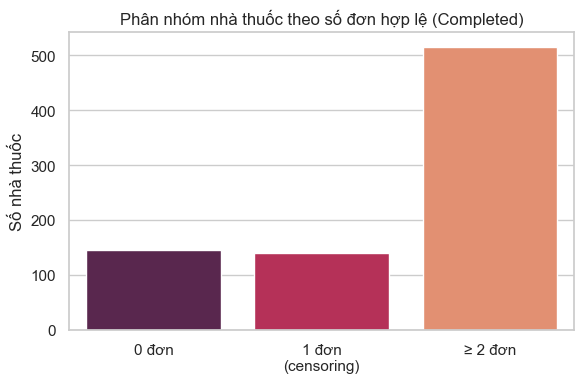

In [25]:
def censor_groups(orders_df, label):
    oc = orders_df.groupby('pharmacy_id')['order_id'].nunique()
    n = data['pharmacies']['pharmacy_id'].nunique()
    n0 = n - oc.index.nunique(); n1 = int((oc==1).sum()); n2 = int((oc>=2).sum())
    return pd.Series({'0 đơn':n0, '1 đơn (bị censoring)':n1, 'từ 2 đơn trở lên':n2,
                      'tỷ lệ censoring %': round((n0+n1)/n*100,1)}, name=label)

cmp = pd.concat([
    censor_groups(od_, 'Toàn bộ trạng thái'),
    censor_groups(od_[od_['order_status']=='Completed'], 'Chỉ đơn Completed'),
], axis=1)
print(cmp.to_string())
print('\nNhận xét: khi chỉ tính đơn hợp lệ (Completed), tỷ lệ nhà thuốc bị censoring tăng từ 28.5% lên 35.5%.')
print('Bài toán tái đặt hàng cần sử dụng đơn Completed; vấn đề này được xử lý ở Bước 4.5.')

g = censor_groups(od_[od_['order_status']=='Completed'], 'Completed')
plt.figure(figsize=(6,4))
sns.barplot(x=['0 đơn','1 đơn\n(censoring)','≥ 2 đơn'],
            y=[g['0 đơn'],g['1 đơn (bị censoring)'],g['từ 2 đơn trở lên']], palette='rocket')
plt.title('Phân nhóm nhà thuốc theo số đơn hợp lệ (Completed)')
plt.ylabel('Số nhà thuốc'); plt.tight_layout(); plt.show()

### 4.5. Phần C — Khảo sát theo định hướng mô hình

Do đề bài yêu cầu chỉ sử dụng mô hình tuyến tính và phân chia dữ liệu theo thời gian, phần này tập trung vào hai nội dung: **multicollinearity** (ảnh hưởng tới việc diễn giải hệ số) và **drift** theo thời gian.

In [26]:
# Khảo sát sơ bộ tương quan giữa các cột số thô. Phân tích multicollinearity đầy đủ
# (ví dụ corr(Frequency, Monetary)) sẽ được thực hiện ở Bước 4 sau khi tạo đặc trưng RFM.
num_pair = pd.concat([
    pd.to_numeric(data['order_lines']['quantity'], errors='coerce'),
    pd.to_numeric(data['order_lines']['unit_price'], errors='coerce'),
], axis=1)
print('Tương quan giữa quantity và unit_price (order_lines):')
print(num_pair.corr().round(3))
print('\nGhi chú: phân tích multicollinearity đầy đủ giữa các đặc trưng (ví dụ Frequency và Monetary)')
print('sẽ được thực hiện ở Bước 4 sau khi các đặc trưng được tạo, theo tinh thần EDA lặp.')

Tương quan giữa quantity và unit_price (order_lines):
            quantity  unit_price
quantity       1.000       0.011
unit_price     0.011       1.000

Ghi chú: phân tích multicollinearity đầy đủ giữa các đặc trưng (ví dụ Frequency và Monetary)
sẽ được thực hiện ở Bước 4 sau khi các đặc trưng được tạo, theo tinh thần EDA lặp.


Mốc thời gian cắt (80% dữ liệu): 2025-08-04 | giai đoạn đầu: 2801 đơn, giai đoạn cuối: 699 đơn


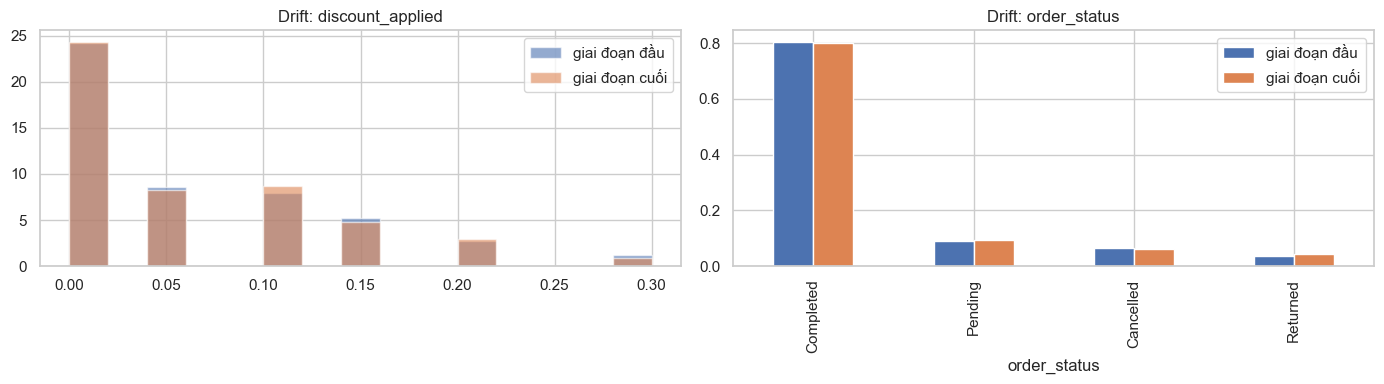

In [27]:
# Drift: so sánh giai đoạn đầu (huấn luyện) và giai đoạn cuối (kiểm tra)
od2 = data['orders'].copy(); od2['d'] = parse_mixed_date(od2['order_date'])
od2 = od2.dropna(subset=['d']).sort_values('d')
cut = od2['d'].quantile(0.8)
early, late = od2[od2['d']<=cut], od2[od2['d']>cut]
print(f'Mốc thời gian cắt (80% dữ liệu): {cut.date()} | giai đoạn đầu: {len(early)} đơn, giai đoạn cuối: {len(late)} đơn')

fig, axes = plt.subplots(1, 2, figsize=(14,4))
ax = axes[0]
ax.hist(pd.to_numeric(early['discount_applied'],errors='coerce').dropna(), bins=15, alpha=.6, label='giai đoạn đầu', density=True)
ax.hist(pd.to_numeric(late['discount_applied'],errors='coerce').dropna(), bins=15, alpha=.6, label='giai đoạn cuối', density=True)
ax.set_title('Drift: discount_applied'); ax.legend()
ax = axes[1]
e = early['order_status'].value_counts(normalize=True); l = late['order_status'].value_counts(normalize=True)
pd.DataFrame({'giai đoạn đầu':e,'giai đoạn cuối':l}).fillna(0).plot(kind='bar', ax=ax)
ax.set_title('Drift: order_status'); plt.tight_layout(); plt.show()

**Trạng thái Phần C** (theo tinh thần EDA là quá trình lặp):
- *Multicollinearity:* khảo sát sơ bộ ở đây, hoàn thiện ở mục 9 sau khi tạo đặc trưng — kết quả: `corr(frequency, monetary) = 0.934`, VIF ≈ 19 (multicollinearity nghiêm trọng), sẽ xử lý bằng bỏ/gộp đặc trưng hoặc hồi quy Ridge ở Bước 6.
- *Cân bằng lớp:* xác định ở Bước 4.5 — lớp dương `will_reorder_45` chiếm **18.2%** (mất cân bằng khoảng 4:1).
- *Liên hệ đặc trưng–nhãn (mục 9):* nhóm RFM và `interval_mean` có ý nghĩa thống kê với nhãn; trong khi **toàn bộ đặc trưng hỗ trợ và tiếp thị không có ý nghĩa** (p > 0.08) nên được giữ ở mức gọn — một phát hiện định hướng việc chọn đặc trưng.
- *Drift:* đã so sánh giai đoạn đầu và cuối ở trên, làm cơ sở cho việc phân chia dữ liệu theo thời gian ở Bước 5.

### 4.6. Tổng hợp các vấn đề dữ liệu phát hiện được

Bảng dưới đây tổng hợp các vấn đề phát hiện trong quá trình EDA, làm đầu vào cho bước làm sạch (Bước 2) và các bước sau.

| # | Bảng / Cột | Vấn đề | Hướng xử lý |
|---|---|---|---|
| 1 | orders.order_status | Các đơn Cancelled/Returned/Pending (khoảng 9.9% trở lên) không phản ánh giao dịch thực sự | Chỉ sử dụng đơn `Completed` khi tính khoảng cách, độ gần đây, doanh số và nhãn (Bước 2.5, 4.5) |
| 2 | Nhiều cột (5/7 bảng) | Thiếu khoảng 4–6% (cơ chế MCAR) | Điền bằng trung vị (biến số) hoặc mode (biến phân loại), ước lượng trên tập huấn luyện |
| 3 | order_lines.quantity | 157 dòng có giá trị âm (nhỏ nhất −50) | Lấy giá trị tuyệt đối hoặc gán thiếu rồi điền |
| 4 | support_tickets.satisfaction_score | Giá trị âm (−1) và thiếu 30% (phần lớn có tính cấu trúc) | Gán giá trị âm thành thiếu; không điền cho phiếu chưa xử lý xong |
| 5 | sales_engagements.is_responded | Biểu diễn nhị phân không đồng nhất (1/0/Yes/TRUE) | Quy chuẩn về {0, 1} |
| 6 | pharmacies.establishment_year | Giá trị 1800 và 2099 (giá trị disguised-missing) | Giới hạn trong [1900, năm hiện tại] và ràng buộc theo ngày onboarding (3 dòng) |
| 7 | Bốn cột ngày | Lẫn ba định dạng khác nhau | Chuẩn hóa bằng hàm `parse_mixed_date()` |
| 8 | is_ordered và is_responded | 41 dòng vi phạm ràng buộc logic | Hiệu chỉnh is_responded = 1 khi is_ordered = 1 |
| 9 | satisfaction_score và resolution_status | 19 dòng phiếu chưa xử lý xong nhưng có điểm | Gán điểm thành thiếu |
| 10 | Toàn vẹn khóa | Không có khóa ngoại lạc | Phép nối an toàn |
| 11 | pharmacies (theo đơn hợp lệ) | Tỷ lệ censoring 35.5% (tính trên đơn Completed, không phải 28.5%) | Xử lý ở Bước 4.5 theo ba nhóm và nêu rõ trong báo cáo |

Kết quả EDA phù hợp với mô tả của đề bài: khoảng 5% giá trị thiếu, khoảng 3% giá trị nhiễu, ngày tháng nhiều định dạng và một số ràng buộc logic bị vi phạm. Các nội dung này được xử lý ở **Bước 2 — Làm sạch dữ liệu**.

## 5. Bước 2 — Làm sạch dữ liệu

Việc làm sạch được chia thành hai loại theo nguy cơ rò rỉ dữ liệu (data leakage):

- **Thao tác tất định (deterministic):** biến đổi từng dòng, **không ước lượng tham số từ phân phối dữ liệu** (chuẩn hóa ngày, quy chuẩn biến nhị phân, lấy trị tuyệt đối giá trị âm, đưa giá trị vô lý về `NaN`, hiệu chỉnh ràng buộc logic, loại bản ghi trùng). Các thao tác này được thực hiện **ngay tại bước này** vì không gây rò rỉ.
- **Điền khuyết dựa trên phân phối (trung vị / mode):** là tham số học từ dữ liệu, nên được **hoãn lại và đưa vào `Pipeline`, ước lượng chỉ trên tập huấn luyện** (Bước 5–6). Tại bước này chỉ chuẩn hóa biểu diễn của giá trị thiếu (đưa giá trị vô lý / disguised-missing về `NaN`) để bộ điền khuyết xử lý sau.

Dữ liệu thô được giữ nguyên trong `data`; bản đã làm sạch lưu trong `clean`.

**Chiến lược xử lý từng vấn đề (kèm lý do):**

| Vấn đề (từ EDA) | Chiến lược | Lý do |
|---|---|---|
| Bốn cột ngày lẫn ba định dạng | `parse_mixed_date()` → datetime | Cần datetime để tính khoảng cách thời gian và phân chia theo thời gian; phân biệt theo dấu phân tách để không nhầm ngày/tháng |
| `is_responded` lẫn 1/0/Yes/TRUE | Ánh xạ về {0, 1} | Biến nhị phân phải đồng nhất mới kiểm tra logic và đưa vào mô hình |
| `quantity` có 157 giá trị âm | Lấy trị tuyệt đối | Giả định lỗi nhập dấu; giữ lại giá trị để tính `total_amount`. Nếu coi là hỏng hoàn toàn thì thay bằng đưa về `NaN` rồi điền |
| `satisfaction_score` ngoài thang 1–5 (các giá trị −1, 0, 7, 9 — tổng 11 dòng) | Đưa về `NaN` | Thang hợp lệ là **1–5** (khối chính dồn ở 1–5 rồi rớt hẳn); 0/7/9/−1 là nhiễu ngoài thang |
| `satisfaction_score` của vé Pending/Escalated | Đưa về `NaN` + cờ `satisfaction_observed`, **không điền** | Thiếu theo thiết kế (structural); điền sẽ tạo thông tin sai lệch |
| `establishment_year` ngoài [1900, năm nay] | Đưa về `NaN` | Giá trị vô lý / (disguised-missing) |
| `establishment_year` lớn hơn năm onboarding | Đưa về `NaN` (kiểm tra phòng vệ) | Không thể thành lập sau khi đã onboard; trong dữ liệu này 3 dòng đó (2030, 2099) đã nằm trong nhóm ngoài biên, không thêm dòng mới |
| `is_ordered`=1 nhưng `is_responded`=0 (41 dòng, 2.3%) | Đặt `is_responded`=1 và thêm cờ `flag_logic_fixed` | Không thể kiểm chứng từ bảng orders (cờ `is_ordered` chỉ khoảng 12% có đơn Completed thật theo sau, kể cả các dòng hợp lệ → đây là mâu thuẫn cờ-với-cờ). Chọn sửa `is_responded` để giữ ràng buộc và **không xóa tín hiệu đặt hàng** (biến hiếm, gần nhãn nhất); nếu đặt `is_ordered`=0 sẽ hủy tín hiệu này |
| Bản ghi trùng | `drop_duplicates` | Tránh đếm trùng |
| Điền khuyết trung vị / mode | **Hoãn vào `Pipeline`, fit trên train** | Là tham số học từ dữ liệu, fit trên cả tập sẽ gây rò rỉ |
| Đơn `Cancelled`/`Returned`/`Pending` | **Giữ lại**, chưa lọc | Vẫn là đặc trưng tiềm năng (tỷ lệ hủy, tỷ lệ trả hàng); chỉ lọc khi tính khoảng cách/nhãn ở Bước 4–4.5 |

### 5.1. Chuẩn hóa kiểu dữ liệu (ngày và biến nhị phân)

In [28]:
clean = {f: data[f].copy() for f in FILES}

# (1) Chuẩn hóa ngày: áp dụng parse_mixed_date cho mọi cột ngày
DATE_COLS = {'orders': ['order_date'], 'pharmacies': ['onboarding_date'],
             'support_tickets': ['created_date'], 'sales_engagements': ['contact_date'],
             'warehouses': ['opened_date']}
for f, cols in DATE_COLS.items():
    for c in cols:
        clean[f][c] = parse_mixed_date(clean[f][c])

# (2) Quy chuẩn biến nhị phân is_responded về {0, 1}
resp_map = {'1': 1, '0': 0, 1: 1, 0: 0, 'Yes': 1, 'No': 0,
            'TRUE': 1, 'True': 1, 'FALSE': 0, 'False': 0}
clean['sales_engagements']['is_responded'] = clean['sales_engagements']['is_responded'].map(resp_map)

print('Sau chuẩn hóa kiểu dữ liệu:')
print('  order_date dtype     :', clean['orders']['order_date'].dtype)
print('  is_responded giá trị :', sorted(clean['sales_engagements']['is_responded'].dropna().unique().tolist()))

Sau chuẩn hóa kiểu dữ liệu:
  order_date dtype     : datetime64[ns]
  is_responded giá trị : [0, 1]


### 5.2. Hiệu chỉnh giá trị không hợp lệ và ràng buộc logic

In [29]:
audit = []

# (3) quantity âm -> lấy trị tuyệt đối
ol = clean['order_lines']
q = pd.to_numeric(ol['quantity'], errors='coerce')
n_neg = int((q < 0).sum())
ol['quantity'] = q.abs()
ol['unit_price'] = pd.to_numeric(ol['unit_price'], errors='coerce')
audit.append(['order_lines.quantity', 'Lấy trị tuyệt đối', 'Giả định lỗi nhập dấu; giữ giá trị để tính total_amount', n_neg])

# (4) satisfaction_score: ngoài thang 1-5 -> NaN; phiếu chưa đóng có điểm -> NaN; thêm cờ quan sát được
# Thang hợp lệ là 1-5 (xem phân phối ở A5): các giá trị -1, 0, 7, 9 là nhiễu ngoài thang.
st = clean['support_tickets']
sat = pd.to_numeric(st['satisfaction_score'], errors='coerce')
n_invalid = int((sat.notna() & ~sat.between(1, 5)).sum())
sat = sat.where(sat.between(1, 5))
open_mask = st['resolution_status'].isin(['Pending', 'Escalated'])
n_open_score = int((open_mask & sat.notna()).sum())
sat = sat.mask(open_mask)
st['satisfaction_score'] = sat
st['satisfaction_observed'] = (~open_mask).astype(int)   # 1: phiếu đã đóng (điểm hợp lệ nếu có)
audit.append(['support_tickets.satisfaction_score', 'Ngoài thang 1-5 -> NaN', 'Thang hợp lệ 1-5; -1/0/7/9 là nhiễu', n_invalid])
audit.append(['support_tickets.satisfaction_score', 'Phiếu chưa đóng có điểm -> NaN', 'Mâu thuẫn logic: chỉ có điểm khi đã xử lý xong', n_open_score])

# (5) establishment_year: ngoài [1900, năm nay] HOẶC lớn hơn năm onboarding -> NaN
ph = clean['pharmacies']
ey = pd.to_numeric(ph['establishment_year'], errors='coerce')
onb_year = ph['onboarding_date'].dt.year
mask_oob = (ey < 1900) | (ey > REF_YEAR)
mask_gt = ey.notna() & onb_year.notna() & (ey > onb_year)
n_oob = int(mask_oob.sum())
n_gt_new = int((mask_gt & ~mask_oob).sum())   # chỉ đếm dòng MỚI ngoài nhóm đã bắt bởi biên
ph['establishment_year'] = ey.where(~(mask_oob | mask_gt))
audit.append(['pharmacies.establishment_year', f'Ngoài [1900, {REF_YEAR}] -> NaN', 'Giá trị disguised-missing', n_oob])
audit.append(['pharmacies.establishment_year', 'Sau năm onboarding -> NaN (phòng vệ)', 'Đã trùng nhóm ngoài biên (2030, 2099); 0 dòng mới', n_gt_new])

# (6) Ràng buộc logic: is_ordered=1 nhưng is_responded=0 -> đặt is_responded=1, kèm cờ kiểm toán
# Lý do chọn sửa is_responded (không phải is_ordered): is_ordered không kiểm chứng được từ bảng
# orders (chỉ ~12% có đơn Completed thật theo sau), nên giữ tín hiệu đặt hàng dương thay vì xóa nó.
se = clean['sales_engagements']
io_ = pd.to_numeric(se['is_ordered'], errors='coerce')
mask_viol = (io_ == 1) & (se['is_responded'] == 0)
n_logic = int(mask_viol.sum())
se.loc[mask_viol, 'is_responded'] = 1
se['flag_logic_fixed'] = 0
se.loc[mask_viol, 'flag_logic_fixed'] = 1   # đánh dấu thay vì ghi đè im lặng (auditable + có thể thành feature)
audit.append(['sales_engagements.is_responded', 'Đặt is_responded=1 + cờ flag_logic_fixed',
               'Cờ-với-cờ, không adjudicate được từ orders (~12% có đơn thật theo sau); giữ tín hiệu đặt hàng hiếm thay vì xóa', n_logic])

# (7) Giá trị sentinel rác '???' trong biến phân loại -> NaN (loại "thiếu trá hình" còn sót)
n_sentinel = int((clean['pharmacies']['pharmacy_type'] == '???').sum())
clean['pharmacies']['pharmacy_type'] = clean['pharmacies']['pharmacy_type'].replace('???', np.nan)
audit.append(['pharmacies.pharmacy_type', "Giá trị '???' -> NaN", 'Sentinel rác (giá trị giả, không phải loại nhà thuốc thật)', n_sentinel])

pd.DataFrame(audit, columns=['Cột', 'Thao tác', 'Lý do', 'Số dòng'])

,Cột,Thao tác,Lý do,Số dòng
0,order_lines.quantity,Lấy trị tuyệt đối,Giả định lỗi nhập dấu; giữ giá trị để tính tot...,157
1,support_tickets.satisfaction_score,Ngoài thang 1-5 -> NaN,Thang hợp lệ 1-5; -1/0/7/9 là nhiễu,11
2,support_tickets.satisfaction_score,Phiếu chưa đóng có điểm -> NaN,Mâu thuẫn logic: chỉ có điểm khi đã xử lý xong,19
3,pharmacies.establishment_year,"Ngoài [1900, 2026] -> NaN",Giá trị disguised-missing,7
4,pharmacies.establishment_year,Sau năm onboarding -> NaN (phòng vệ),"Đã trùng nhóm ngoài biên (2030, 2099); 0 dòng mới",0
5,sales_engagements.is_responded,Đặt is_responded=1 + cờ flag_logic_fixed,"Cờ-với-cờ, không adjudicate được từ orders (~1...",41
6,pharmacies.pharmacy_type,Giá trị '???' -> NaN,"Sentinel rác (giá trị giả, không phải loại nhà...",5


### 5.3. Loại bản ghi trùng và rà soát giá trị thiếu còn lại

In [30]:
# (7) Loại bản ghi trùng toàn dòng (phòng vệ; EDA cho thấy hiện không có)
for f in FILES:
    before = len(clean[f])
    clean[f] = clean[f].drop_duplicates().reset_index(drop=True)
    if before != len(clean[f]):
        print(f'{f}: loại {before - len(clean[f])} dòng trùng')
print('Hoàn tất loại trùng.')

# (8) Giá trị thiếu CÒN LẠI sau làm sạch tất định -> phần lớn điền bằng Pipeline (fit trên train)
print('\nGiá trị còn thiếu sau làm sạch (sẽ điền trong Pipeline ở Bước 5-6, fit trên train):')
for f in FILES:
    m = (clean[f].isnull().mean() * 100).round(1)
    m = m[m > 0]
    if len(m):
        print(f'  {f}: ' + ', '.join(f'{c}={v}%' for c, v in m.items()))
print('\nNgoại lệ: satisfaction_score (thiếu chủ yếu là structural) KHÔNG đưa vào bộ điền khuyết thô;')
print('cột này được tổng hợp trung bình theo nhà thuốc (bỏ qua NaN) ở Bước 4.')

Hoàn tất loại trùng.

Giá trị còn thiếu sau làm sạch (sẽ điền trong Pipeline ở Bước 5-6, fit trên train):
  pharmacies: pharmacy_type=6.2%, establishment_year=5.0%, province=4.1%, acquisition_channel=4.6%, credit_tier=5.9%
  orders: payment_term=5.0%, payment_method=4.2%, discount_applied=5.6%, order_status=4.8%
  order_lines: quantity=5.1%, unit_price=4.9%
  products: sub_category=4.7%, manufacturer=4.7%, base_price=4.7%
  support_tickets: channel=4.1%, issue_type=5.7%, satisfaction_score=34.3%
  sales_engagements: channel=4.4%, engagement_type=5.3%, offer_value=5.3%
  warehouses: warehouse_type=4.0%

Ngoại lệ: satisfaction_score (thiếu chủ yếu là structural) KHÔNG đưa vào bộ điền khuyết thô;
cột này được tổng hợp trung bình theo nhà thuốc (bỏ qua NaN) ở Bước 4.


### 5.4. Xem nhanh bản dữ liệu đã làm sạch

In [31]:
# Kiểm tra trực quan kết quả làm sạch trên từng bảng (kiểu ngày đã đổi, cờ mới đã có...)
for table in clean:
    print(f'\n===== {table} =====')
    display(clean[table].head())


===== pharmacies =====


,pharmacy_id,pharmacy_type,establishment_year,province,region,onboarding_date,acquisition_channel,credit_tier
0,PH0001,Quầy thuốc,2017.0,Đồng Nai,Nam,2021-03-18,Web portal,C
1,PH0002,NaN,2016.0,Khánh Hòa,Trung,2022-01-16,Sales rep,B
2,PH0003,Quầy thuốc,1996.0,An Giang,Nam,2021-04-15,Web portal,B
3,PH0004,Nhà thuốc,2009.0,Hải Dương,Bắc,2022-02-03,Web portal,A
4,PH0005,Quầy thuốc,2005.0,NaN,Trung,2021-01-08,Web portal,B



===== orders =====


,order_id,pharmacy_id,warehouse_id,order_date,payment_term,payment_method,discount_applied,order_status
0,O00001,PH0001,W001,2022-05-10,Net30,Chuyển khoản,0.05,Completed
1,O00002,PH0001,W015,2025-05-06,COD,Tiền mặt,0.00,Completed
2,O00003,PH0001,W022,2022-04-04,COD,Tiền mặt,0.30,Completed
3,O00004,PH0001,W021,2021-05-19,COD,Tiền mặt,0.30,Completed
4,O00005,PH0002,W021,2025-02-16,Net30,Chuyển khoản,0.00,Cancelled



===== order_lines =====


...

,ticket_id,pharmacy_id,created_date,channel,issue_type,resolution_status,satisfaction_score,satisfaction_observed
0,T0001,PH0234,2025-06-28,Call,Giao trễ,Pending,NaN,0
1,T0002,PH0451,2025-01-27,Zalo,Công nợ,Escalated,NaN,0
2,T0003,PH0323,2025-07-08,Call,Sai hàng,Resolved,1.0,1
3,T0004,PH0413,2024-03-15,Sales rep,Chất lượng,Resolved,1.0,1
4,T0005,PH0007,2022-11-05,Zalo,Công nợ,Resolved,2.0,1



===== sales_engagements =====


,engagement_id,pharmacy_id,contact_date,channel,engagement_type,is_responded,is_ordered,offer_value,flag_logic_fixed
0,E00001,PH0357,2022-12-28,Zalo,Khuyến mãi,1,0,645000.0,0
1,E00002,PH0189,2025-08-04,Call,Nhắc đặt lại,0,0,0.0,0
2,E00003,PH0012,2025-12-12,Zalo,Nhắc đặt lại,1,1,0.0,0
3,E00004,PH0728,2025-04-20,Zalo,Thăm trình dược,1,1,0.0,0
4,E00005,PH0542,2024-05-03,Zalo,Nhắc đặt lại,1,1,0.0,0



===== warehouses =====


,warehouse_id,warehouse_name,region,warehouse_type,opened_date
0,W001,Kho Bắc 01,Bắc,Trung tâm,2015-08-13
1,W002,Kho Trung 02,Trung,Trung tâm,2022-06-06
2,W003,Kho Nam 03,Nam,Trung tâm,2021-09-01
3,W004,Kho Bắc 04,Bắc,Trung tâm,2020-07-28
4,W005,Kho Trung 05,Trung,Trung tâm,2019-10-11


**Kết luận Bước 2:**
- Đã thực hiện toàn bộ thao tác làm sạch **tất định**: chuẩn hóa 5 cột ngày về kiểu datetime, quy chuẩn `is_responded` về {0, 1}, lấy trị tuyệt đối các giá trị âm của `quantity`, đưa các giá trị vô lý của `satisfaction_score` và `establishment_year` về `NaN` (gồm cả 3 dòng có năm thành lập sau năm onboarding), hiệu chỉnh các vi phạm ràng buộc logic, và bổ sung cờ `satisfaction_observed`.
- **Xử lý thiếu theo thiết kế đúng cách:** phần thiếu của `satisfaction_score` ở vé chưa đóng được giữ là `NaN` và **không** đưa vào bộ điền khuyết. Ở Bước 4, đặc trưng hài lòng được tính bằng **trung bình các điểm đã quan sát theo từng nhà thuốc (bỏ qua `NaN`)**, nên phần thiếu cấu trúc tự động bị loại trừ chứ không bị điền bằng trung vị.
- **Điền khuyết theo phân phối (trung vị / mode) được hoãn lại** và đưa vào `Pipeline`, chỉ ước lượng trên tập huấn luyện (Bước 5–6) để tránh rò rỉ dữ liệu.
- **Giữ lại** các đơn `Cancelled`/`Returned`/`Pending`: việc lọc đơn hợp lệ (`Completed`) chỉ áp dụng khi tính khoảng cách và nhãn (Bước 2.5 và 4.5); ngoài ra các trạng thái này còn dùng để tạo đặc trưng tỷ lệ hủy và tỷ lệ trả hàng ở Bước 4.
- **Đánh dấu thay vì ghi đè im lặng:** 41 dòng được sửa `is_responded` đồng thời được gắn cờ `flag_logic_fixed`, vừa cho phép kiểm tra lại (auditable), vừa có thể trở thành đặc trưng tiềm năng (nhà thuốc có tương tác "lệch logic" có thể khác biệt). Sở dĩ sửa `is_responded` chứ không phải `is_ordered` vì `is_ordered` không kiểm chứng được từ bảng orders (chỉ khoảng 12% engagement có `is_ordered`=1 thực sự có đơn Completed theo sau), nên ưu tiên giữ lại tín hiệu đặt hàng — vốn hiếm và gần nhãn nhất.
- **Lưu ý quyết định:** giá trị âm của `quantity` được giả định là lỗi nhập dấu nên lấy trị tuyệt đối nhằm giữ lại giá trị đơn hàng; nếu xem là dữ liệu hỏng hoàn toàn thì có thể thay bằng cách đưa về `NaN` rồi điền.

## 6. Bước 2.5 — Tích hợp dữ liệu và tính `total_amount`

Mục tiêu: ghép 7 bảng về **grain mục tiêu là một dòng / một nhà thuốc** và tính cột phái sinh `total_amount`. Ba điểm cốt lõi:

1. **`total_amount = SUM(quantity × unit_price)` theo từng đơn, rồi mới nhân `(1 − discount_applied)`** — chiết khấu áp ở **mức đơn sau khi cộng**, không áp lên từng dòng chi tiết.
2. **Phép nối cuối `pharmacies ← orders` dùng LEFT JOIN rồi điền 0** — để giữ 110 nhà thuốc chưa phát sinh đơn (dùng INNER sẽ loại mất nhóm bị censoring).
3. **Khi tính tiền và khoảng cách chỉ dùng đơn `Completed`** — đơn `Cancelled`/`Returned`/`Pending` không phải giao dịch thật; nhưng vẫn giữ để tạo đặc trưng tỷ lệ hủy / trả hàng.

> **Lưu ý chống rò rỉ:** bảng tích hợp ở bước này dùng *toàn bộ lịch sử* để minh họa cơ chế ghép. Bảng đặc trưng phục vụ mô hình sẽ được **dựng lại với mốc cắt thời gian T** ở Bước 4.5 (chỉ dùng dữ liệu ≤ T) nhằm tránh rò rỉ tương lai.

### 6.1. Tính `total_amount` cho mỗi đơn hàng

In [32]:
# Ghép order_lines với products (LEFT) để lấy base_price phục vụ điền khuyết giá theo miền
lines = clean['order_lines'].merge(
    clean['products'][['product_id', 'base_price']], on='product_id', how='left')

# Điền khuyết ở mức dòng để tính tiền:
#  - unit_price thiếu -> lấy base_price của sản phẩm (điền theo MIỀN, không học từ phân phối)
#  - phần còn thiếu (sản phẩm cũng thiếu base_price) và quantity thiếu -> trung vị (xấp xỉ, ~5% dòng)
n_up_missing = int(lines['unit_price'].isna().sum())
lines['unit_price'] = lines['unit_price'].fillna(lines['base_price'])
n_up_by_base = n_up_missing - int(lines['unit_price'].isna().sum())
lines['unit_price'] = lines['unit_price'].fillna(lines['unit_price'].median())
n_qty_missing = int(lines['quantity'].isna().sum())
lines['quantity'] = lines['quantity'].fillna(lines['quantity'].median())

lines['line_amount'] = lines['quantity'] * lines['unit_price']

# SUM theo đơn TRƯỚC, rồi mới áp chiết khấu ở mức đơn
order_subtotal = lines.groupby('order_id')['line_amount'].sum()
orders_e = clean['orders'].copy()
orders_e['order_subtotal'] = orders_e['order_id'].map(order_subtotal)
discount = orders_e['discount_applied'].fillna(0)          # thiếu chiết khấu = không giảm giá
orders_e['total_amount'] = orders_e['order_subtotal'] * (1 - discount)

print(f'Điền unit_price thiếu: {n_up_missing} dòng (trong đó {n_up_by_base} lấy theo base_price), '
      f'quantity thiếu: {n_qty_missing} dòng')
print(f'total_amount: min={orders_e["total_amount"].min():,.0f}, '
      f'trung vị={orders_e["total_amount"].median():,.0f}, max={orders_e["total_amount"].max():,.0f}')
orders_e[['order_id','pharmacy_id','order_status','discount_applied','order_subtotal','total_amount']].head()

Điền unit_price thiếu: 383 dòng (trong đó 369 lấy theo base_price), quantity thiếu: 391 dòng
total_amount: min=225,165, trung vị=12,016,860, max=47,293,000


,order_id,pharmacy_id,order_status,discount_applied,order_subtotal,total_amount
0,O00001,PH0001,Completed,0.05,2504900.0,2379655.0
1,O00002,PH0001,Completed,0.00,19600800.0,19600800.0
2,O00003,PH0001,Completed,0.30,17941500.0,12559050.0
3,O00004,PH0001,Completed,0.30,13403000.0,9382100.0
4,O00005,PH0002,Cancelled,0.00,8269800.0,8269800.0


Chiết khấu được áp ở mức đơn sau khi cộng các dòng (kiểm chứng: `total_amount = order_subtotal × (1 − discount)`). Giá trị thiếu của `unit_price` được điền theo `base_price` của sản phẩm (điền theo miền, không gây rò rỉ); phần nhỏ còn lại và `quantity` thiếu được điền bằng trung vị — đây là xấp xỉ cho việc dựng đặc trưng tiền tệ, ảnh hưởng tới khoảng 5% dòng.

> **Nhất quán chống rò rỉ:** trung vị dùng để điền ở đây tính trên toàn bộ dữ liệu, chỉ phục vụ bảng tích hợp minh họa (tác động không đáng kể: trung vị `unit_price` train-only chênh khoảng 0.3%, `quantity` không đổi). Khi dựng đặc trưng theo mốc thời gian T ở Bước 4, các giá trị điền được tính **chỉ trên dữ liệu ≤ T**.

### 6.2. Tích hợp về grain một dòng / một nhà thuốc

In [33]:
# (a) Tổng hợp từ đơn HỢP LỆ (Completed): tần suất, doanh số, mốc đơn đầu/cuối
comp = orders_e[orders_e['order_status'] == 'Completed']
agg_completed = comp.groupby('pharmacy_id').agg(
    n_orders=('order_id', 'nunique'),
    monetary=('total_amount', 'sum'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'),
)

# (b) Tổng hợp từ MỌI trạng thái: phục vụ đặc trưng tỷ lệ hủy / trả hàng
agg_all = orders_e.groupby('pharmacy_id').agg(
    n_all_orders=('order_id', 'nunique'),
    n_cancelled=('order_status', lambda s: (s == 'Cancelled').sum()),
    n_returned=('order_status', lambda s: (s == 'Returned').sum()),
)

# (c) Tổng hợp support_tickets về mức nhà thuốc (avg_satisfaction bỏ qua NaN -> loại structural)
agg_ticket = clean['support_tickets'].groupby('pharmacy_id').agg(
    n_tickets=('ticket_id', 'nunique'),
    avg_satisfaction=('satisfaction_score', 'mean'),
)

# (d) Tổng hợp sales_engagements về mức nhà thuốc
agg_eng = clean['sales_engagements'].groupby('pharmacy_id').agg(
    n_engagements=('engagement_id', 'nunique'),
    response_rate=('is_responded', 'mean'),
)

# (e) Ghép orders với warehouses để lấy VÙNG kho; tổng hợp số kho và vùng kho chính mỗi nhà thuốc
ord_wh = orders_e.merge(clean['warehouses'][['warehouse_id', 'region']].rename(columns={'region': 'wh_region'}),
                        on='warehouse_id', how='left')
def _mode(s):
    m = s.dropna().mode()
    return m.iat[0] if len(m) else np.nan
agg_wh = ord_wh.groupby('pharmacy_id').agg(
    n_warehouses=('warehouse_id', 'nunique'),
    main_warehouse_region=('wh_region', _mode))

print('Đã tổng hợp 5 nhóm về mức nhà thuốc:',
      [len(x) for x in [agg_completed, agg_all, agg_ticket, agg_eng, agg_wh]], 'nhà thuốc có dữ liệu mỗi nhóm')

Đã tổng hợp 5 nhóm về mức nhà thuốc: [655, 690, 457, 715, 690] nhà thuốc có dữ liệu mỗi nhóm


In [34]:
# Phép nối cuối: LEFT JOIN từ pharmacies để GIỮ toàn bộ 800 nhà thuốc (kể cả 0 đơn)
master = clean['pharmacies'].copy()
for agg in [agg_completed, agg_all, agg_ticket, agg_eng, agg_wh]:
    master = master.merge(agg, on='pharmacy_id', how='left')

# Điền 0 cho các cột ĐẾM/DOANH SỐ ở nhà thuốc không khớp (0 đơn, 0 ticket...)
count_cols = ['n_orders', 'monetary', 'n_all_orders', 'n_cancelled', 'n_returned',
              'n_tickets', 'n_engagements', 'n_warehouses']
master[count_cols] = master[count_cols].fillna(0)

# Đặc trưng tỷ lệ (chia có bảo vệ chia cho 0)
master['cancel_rate'] = np.where(master['n_all_orders'] > 0, master['n_cancelled'] / master['n_all_orders'], 0)
master['return_rate'] = np.where(master['n_all_orders'] > 0, master['n_returned'] / master['n_all_orders'], 0)

print('Bảng tích hợp master:', master.shape)
print('Số nhà thuốc giữ lại            :', master['pharmacy_id'].nunique(), '(kỳ vọng 800)')
print('Số nhà thuốc 0 đơn Completed    :', int((master['n_orders'] == 0).sum()))
print('avg_satisfaction còn NaN (không có điểm quan sát):', int(master['avg_satisfaction'].isna().sum()),
      '-> điền trong Pipeline')
master.head()

Bảng tích hợp master: (800, 23)
Số nhà thuốc giữ lại            : 800 (kỳ vọng 800)
Số nhà thuốc 0 đơn Completed    : 145
avg_satisfaction còn NaN (không có điểm quan sát): 453 -> điền trong Pipeline


,pharmacy_id,pharmacy_type,establishment_year,province,region,onboarding_date,acquisition_channel,credit_tier,n_orders,monetary,first_order,last_order,n_all_orders,n_cancelled,n_returned,n_tickets,avg_satisfaction,n_engagements,response_rate,n_warehouses,main_warehouse_region,cancel_rate,return_rate
0,PH0001,Quầy thuốc,2017.0,Đồng Nai,Nam,2021-03-18,Web portal,C,4.0,43921605.0,2021-05-19,2025-05-06,4.0,0.0,0.0,1.0,4.0,1.0,1.000000,4.0,Bắc,0.00,0.0
1,PH0002,NaN,2016.0,Khánh Hòa,Trung,2022-01-16,Sales rep,B,3.0,21928615.0,2023-03-29,2025-03-28,4.0,1.0,0.0,1.0,1.0,1.0,0.000000,4.0,Nam,0.25,0.0
2,PH0003,Quầy thuốc,1996.0,An Giang,Nam,2021-04-15,Web portal,B,3.0,34941500.0,2022-11-05,2025-09-19,3.0,0.0,0.0,0.0,NaN,3.0,0.333333,2.0,Nam,0.00,0.0
3,PH0004,Nhà thuốc,2009.0,Hải Dương,Bắc,2022-02-03,Web portal,A,3.0,15922140.0,2022-09-14,2025-07-17,5.0,1.0,0.0,1.0,NaN,4.0,0.250000,5.0,Bắc,0.20,0.0
4,PH0005,Quầy thuốc,2005.0,NaN,Trung,2021-01-08,Web portal,B,3.0,45770395.0,2022-12-17,2025-08-08,3.0,0.0,0.0,1.0,2.0,1.0,1.000000,3.0,Trung,0.00,0.0


**Kết luận Bước 2.5:**
- `total_amount` được tính đúng quy ước: cộng `quantity × unit_price` theo từng đơn rồi mới áp `(1 − discount_applied)` ở mức đơn.
- Đã tích hợp **cả 7 bảng** về grain một dòng / một nhà thuốc: orders, order_lines, products, warehouses (qua các phép nối INNER/LEFT như mô tả ở mục 4.3) và pharmacies, support_tickets, sales_engagements (tổng hợp rồi LEFT JOIN).
- **Phép nối cuối dùng LEFT JOIN và điền 0**, giữ đầy đủ **800 nhà thuốc** — trong đó các nhà thuốc 0 đơn (nhóm bị censoring) được bảo toàn để phân tích, thay vì bị loại như khi dùng INNER JOIN.
- `avg_satisfaction` ở mức nhà thuốc đã loại phần thiếu cấu trúc (trung bình bỏ qua NaN); nhà thuốc không có điểm quan sát nào để `NaN`, sẽ điền trong `Pipeline`.
- Bảng `master` là nền cho **Bước 4 (xây dựng đặc trưng RFM và các nhóm hành vi)**, trong đó các đặc trưng sẽ được tính lại theo mốc thời gian T để chống rò rỉ.

## 7. Bước 4 — Xây dựng đặc trưng (tại mốc thời gian T)

Đây là bước trọng tâm. Mọi đặc trưng được tính **chỉ từ dữ liệu ≤ T** (gate cả orders, support_tickets, sales_engagements theo T) để chống rò rỉ. Các nhóm đặc trưng:
- **RFM**: Recency (T − ngày đơn cuối), Frequency (số đơn Completed), Monetary (tổng `total_amount`), kèm phân hạng tứ phân vị A/B/C/D.
- **Khoảng cách giữa các đơn**: trung bình (`interval_mean`) và độ lệch chuẩn (`interval_std`) khoảng cách giữa các đơn — ứng viên tín hiệu cho hành vi tái đặt, được kiểm chứng định lượng ở mục 9.
- **Hành vi**: giá trị trung bình mỗi đơn (AOV), tỷ lệ hủy, tỷ lệ trả hàng.
- **Hỗ trợ (gọn)**: số phiếu, tỷ lệ chưa xử lý, điểm hài lòng trung bình.
- **Tiếp thị (gọn)**: số lần tiếp cận, tỷ lệ phản hồi, tỷ lệ đặt hàng sau tiếp cận.
- **Thuộc tính nhà thuốc**: loại, vùng, hạng tín dụng, kênh thu hút, thâm niên.

### 7.1. Mốc thời gian T và lọc dữ liệu ≤ T

In [35]:
# T lùi 45 ngày so với ngày dữ liệu cuối -> cửa sổ tái đặt (T, T+45] quan sát được đầy đủ
all_event_dates = pd.concat([orders_e['order_date'],
                             clean['support_tickets']['created_date'],
                             clean['sales_engagements']['contact_date']])
DATA_END = all_event_dates.max()
HORIZON = 45
T = DATA_END - pd.Timedelta(days=HORIZON)
print(f'Ngày dữ liệu cuối: {DATA_END.date()} | T = {T.date()} | cửa sổ nhãn: ({T.date()}, {DATA_END.date()}]')

# Gate MỌI bảng theo T (không riêng orders) — chống rò rỉ tương lai vào đặc trưng
orders_T  = orders_e[orders_e['order_date'] <= T]
comp_T    = orders_T[orders_T['order_status'] == 'Completed']
tickets_T = clean['support_tickets'][clean['support_tickets']['created_date'] <= T]
eng_T     = clean['sales_engagements'][clean['sales_engagements']['contact_date'] <= T]
print(f'Bản ghi ≤ T: orders={len(orders_T)}, completed={len(comp_T)}, '
      f'tickets={len(tickets_T)}, engagements={len(eng_T)}')

# An toàn: cửa sổ nhãn (T, DATA_END] phải có đơn Completed, nếu không nhãn dương sẽ rỗng
n_in_window = int(((orders_e['order_status'] == 'Completed') &
                   (orders_e['order_date'] > T) & (orders_e['order_date'] <= DATA_END)).sum())
assert n_in_window > 0, 'Cửa sổ nhãn không có đơn Completed nào — cần xem lại mốc T'
print(f'Số đơn Completed trong cửa sổ nhãn: {n_in_window} (hợp lệ, > 0)')

Ngày dữ liệu cuối: 2025-12-31 | T = 2025-11-16 | cửa sổ nhãn: (2025-11-16, 2025-12-31]
Bản ghi ≤ T: orders=3279, completed=2517, tickets=657, engagements=1683
Số đơn Completed trong cửa sổ nhãn: 164 (hợp lệ, > 0)


### 7.2. Tính các nhóm đặc trưng

In [36]:
# (1) RFM từ đơn Completed ≤ T
rfm = comp_T.groupby('pharmacy_id').agg(
    frequency=('order_id', 'nunique'),
    monetary=('total_amount', 'sum'),
    first_order=('order_date', 'min'),
    last_order=('order_date', 'max'))
rfm['recency'] = (T - rfm['last_order']).dt.days
rfm['aov'] = rfm['monetary'] / rfm['frequency']
rfm['active_span'] = (rfm['last_order'] - rfm['first_order']).dt.days

# (2) Độ đều khoảng cách giữa các đơn
def interval_stats(s):
    g = np.diff(np.sort(s.values)).astype('timedelta64[D]').astype(float)
    if len(g) == 0:
        return pd.Series({'interval_mean': np.nan, 'interval_std': np.nan})
    return pd.Series({'interval_mean': g.mean(), 'interval_std': g.std()})
iv = comp_T.groupby('pharmacy_id')['order_date'].apply(interval_stats).unstack()

# (3) Hành vi hủy/trả từ MỌI trạng thái ≤ T
beh = orders_T.groupby('pharmacy_id').agg(
    n_all=('order_id', 'nunique'),
    n_cancel=('order_status', lambda s: (s == 'Cancelled').sum()),
    n_return=('order_status', lambda s: (s == 'Returned').sum()))
beh['cancel_rate'] = beh['n_cancel'] / beh['n_all']
beh['return_rate'] = beh['n_return'] / beh['n_all']

# (4) Hỗ trợ (gọn)
sup = tickets_T.groupby('pharmacy_id').agg(
    n_tickets=('ticket_id', 'nunique'),
    unresolved_rate=('resolution_status', lambda s: s.isin(['Pending', 'Escalated']).mean()),
    avg_satisfaction=('satisfaction_score', 'mean'))

# (5) Tiếp thị (gọn)
mkt = eng_T.groupby('pharmacy_id').agg(
    n_engagements=('engagement_id', 'nunique'),
    response_rate=('is_responded', 'mean'),
    eng_order_rate=('is_ordered', 'mean'))

# (6) Thuộc tính nhà thuốc
attrs = clean['pharmacies'].set_index('pharmacy_id')[
    ['pharmacy_type', 'region', 'credit_tier', 'acquisition_channel', 'establishment_year']].copy()
attrs['tenure_years'] = T.year - attrs['establishment_year']

print('Đã tính 6 nhóm đặc trưng tại T.')

Đã tính 6 nhóm đặc trưng tại T.


In [37]:
# Ghép thành bảng đặc trưng cho QUẦN THỂ mô hình = nhà thuốc có >=1 đơn Completed <= T
feat = (rfm.join(iv).join(beh[['cancel_rate', 'return_rate']])
            .join(sup).join(mkt).join(attrs, how='left'))
for c in ['n_tickets', 'n_engagements']:
    feat[c] = feat[c].fillna(0)
for c in ['cancel_rate', 'return_rate', 'unresolved_rate', 'response_rate', 'eng_order_rate']:
    feat[c] = feat[c].fillna(0)
feat = feat.reset_index()

# Cờ has_multi_order: 0 cho nhà thuốc chỉ 1 đơn (interval_mean = NaN, chưa có khoảng cách nào)
# -> tách nhóm "chưa lặp lại" khỏi nhóm thực sự có gap điển hình trước khi điền khuyết
feat['has_multi_order'] = (feat['frequency'] >= 2).astype(int)

# Phân hạng RFM tứ phân vị A/B/C/D (A là tốt nhất)
def grade(s, higher_is_better):
    labels = ['D', 'C', 'B', 'A'] if higher_is_better else ['A', 'B', 'C', 'D']
    return pd.qcut(s.rank(method='first'), 4, labels=labels)
feat['R_grade'] = grade(feat['recency'], higher_is_better=False)   # recency nhỏ = tốt
feat['F_grade'] = grade(feat['frequency'], higher_is_better=True)
feat['M_grade'] = grade(feat['monetary'], higher_is_better=True)

print('Bảng đặc trưng:', feat.shape, '| quần thể (>=1 đơn Completed <= T):', feat['pharmacy_id'].nunique())
print('Nhà thuốc 0 đơn Completed <= T bị loại khỏi quần thể (giữ cho EDA/khuyến nghị):',
      clean['pharmacies']['pharmacy_id'].nunique() - feat['pharmacy_id'].nunique())
feat.head()

Bảng đặc trưng: (647, 28) | quần thể (>=1 đơn Completed <= T): 647
Nhà thuốc 0 đơn Completed <= T bị loại khỏi quần thể (giữ cho EDA/khuyến nghị): 153


,pharmacy_id,frequency,monetary,first_order,last_order,recency,aov,active_span,interval_mean,interval_std,cancel_rate,return_rate,n_tickets,unresolved_rate,avg_satisfaction,n_engagements,response_rate,eng_order_rate,pharmacy_type,region,credit_tier,acquisition_channel,establishment_year,tenure_years,has_multi_order,R_grade,F_grade,M_grade
0,PH0001,4,43921605.0,2021-05-19,2025-05-06,194,1.098040e+07,1448,482.666667,446.190791,0.00,0.0,1.0,0.0,4.0,1.0,1.000000,0.00,Quầy thuốc,Nam,C,Web portal,2017.0,8.0,1,C,B,B
1,PH0002,3,21928615.0,2023-03-29,2025-03-28,233,7.309538e+06,730,365.000000,59.000000,0.25,0.0,1.0,0.0,1.0,1.0,0.000000,0.00,NaN,Trung,B,Sales rep,2016.0,9.0,1,C,C,C
2,PH0003,3,34941500.0,2022-11-05,2025-09-19,58,1.164717e+07,1049,524.500000,487.500000,0.00,0.0,0.0,0.0,NaN,3.0,0.333333,0.00,Quầy thuốc,Nam,B,Web portal,1996.0,29.0,1,A,C,C
3,PH0004,3,15922140.0,2022-09-14,2025-07-17,122,5.307380e+06,1037,518.500000,373.500000,0.20,0.0,1.0,1.0,NaN,4.0,0.250000,0.25,Nhà thuốc,Bắc,A,Web portal,2009.0,16.0,1,B,C,D
4,PH0005,3,45770395.0,2022-12-17,2025-08-08,100,1.525680e+07,965,482.500000,122.500000,0.00,0.0,1.0,0.0,2.0,1.0,1.000000,1.00,Quầy thuốc,Trung,B,Web portal,2005.0,20.0,1,B,C,B


## 8. Bước 4.5 — Xây dựng nhãn mục tiêu và xử lý censoring

Tại mốc T, với mỗi nhà thuốc trong quần thể (có ≥1 đơn Completed ≤ T):
- **Phân loại** `will_reorder_45`: có đơn Completed trong cửa sổ (T, T+45] hay không.
- **Hồi quy** `days_until_next`: số ngày từ T đến đơn Completed kế tiếp; `NaN` nếu không tái đặt trong cửa sổ (bị censoring bên phải).

In [38]:
future_comp = orders_e[(orders_e['order_status'] == 'Completed') &
                       (orders_e['order_date'] > T) & (orders_e['order_date'] <= DATA_END)]
reorder_set = set(future_comp['pharmacy_id'])
feat['will_reorder_45'] = feat['pharmacy_id'].isin(reorder_set).astype(int)
next_date = future_comp.groupby('pharmacy_id')['order_date'].min()
feat['days_until_next'] = (feat['pharmacy_id'].map(next_date) - T).dt.days

vc = feat['will_reorder_45'].value_counts()
rate = feat['will_reorder_45'].mean()
print('Phân loại will_reorder_45:'); print(vc)
print(f'Tỷ lệ lớp dương: {rate*100:.1f}%  ->  mất cân bằng ~ {((1-rate)/rate):.0f}:1')
print(f'\nHồi quy days_until_next: có giá trị (tái đặt) = {feat["days_until_next"].notna().sum()}, '
      f'bị censoring (NaN) = {feat["days_until_next"].isna().sum()}')
print(f'  days_until_next của nhóm tái đặt: trung vị = {feat["days_until_next"].median()} ngày')

Phân loại will_reorder_45:
will_reorder_45
0    529
1    118
Name: count, dtype: int64
Tỷ lệ lớp dương: 18.2%  ->  mất cân bằng ~ 4:1

Hồi quy days_until_next: có giá trị (tái đặt) = 118, bị censoring (NaN) = 529
  days_until_next của nhóm tái đặt: trung vị = 20.0 ngày


**Xử lý censoring:**
- **Phạm vi mô hình:** chỉ dự báo tái đặt cho **647 nhà thuốc đang hoạt động** (có ≥1 đơn Completed ≤ T). **153 nhà thuốc không có lịch sử** (110 chưa từng mua thành công + nhóm chỉ có đơn hỏng/đơn đầu trong cửa sổ) nằm **ngoài** bài toán tái đặt — đây là đối tượng cho chiến lược **acquisition / win-back** riêng, sẽ nêu ở khuyến nghị Bước 7, không phải bị bỏ sót.
- Nhà thuốc **không tái đặt trong (T, T+45]**: nhãn phân loại = 0; biến hồi quy `days_until_next` bị **censoring bên phải** (để `NaN`). Với bài hồi quy chỉ huấn luyện trên nhóm có tái đặt và nêu rõ giới hạn này; **trọng tâm là bài phân loại**.
- Lớp dương rất nhỏ -> bắt buộc dùng **F1 / PR-AUC**, `class_weight='balanced'` và tinh chỉnh ngưỡng (Bước 6), không dùng Accuracy.

## 9. Phân tích đặc trưng: multicollinearity và liên hệ với nhãn

Hoàn thiện hai nội dung đã nêu ở Phần C (mục 4.5): kiểm tra **multicollinearity** (ảnh hưởng tới việc diễn giải hệ số) và **liên hệ từng đặc trưng với nhãn** bằng tương quan điểm-nhị phân (point-biserial).

In [39]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pointbiserialr

NUM_FEATS = ['recency', 'frequency', 'monetary', 'aov', 'active_span',
             'interval_mean', 'interval_std', 'cancel_rate', 'return_rate',
             'n_tickets', 'unresolved_rate', 'avg_satisfaction',
             'n_engagements', 'response_rate', 'eng_order_rate', 'tenure_years']

# Multicollinearity: ma trận tương quan + VIF (trên đặc trưng đã standardize, điền trung vị để chẩn đoán)
Xf = feat[NUM_FEATS].apply(lambda s: pd.to_numeric(s, errors='coerce'))
Xf = Xf.fillna(Xf.median())
Xs = (Xf - Xf.mean()) / Xf.std(ddof=0)

vif = {}
for col in NUM_FEATS:
    others = [c for c in NUM_FEATS if c != col]
    r2 = LinearRegression().fit(Xs[others], Xs[col]).score(Xs[others], Xs[col])
    vif[col] = round(1 / (1 - r2), 1) if r2 < 1 else np.inf
print('corr(frequency, monetary) =', round(feat['frequency'].corr(feat['monetary']), 3))
print('\nVIF (>10 = multicollinearity nghiêm trọng):')
print(pd.Series(vif).sort_values(ascending=False).to_string())

corr(frequency, monetary) = 0.934

VIF (>10 = multicollinearity nghiêm trọng):
frequency           19.0
monetary            18.4
active_span          5.7
interval_mean        2.8
aov                  2.3
interval_std         2.1
response_rate        1.4
eng_order_rate       1.4
unresolved_rate      1.2
recency              1.2
n_engagements        1.1
n_tickets            1.1
cancel_rate          1.0
return_rate          1.0
avg_satisfaction     1.0
tenure_years         1.0


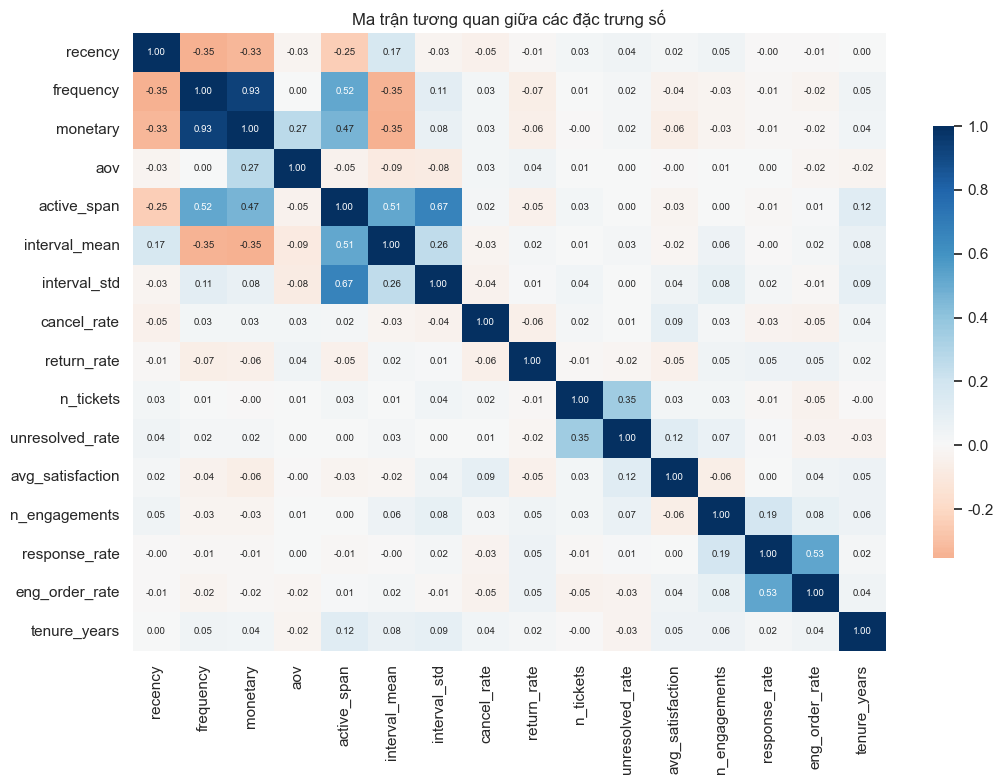

In [40]:
plt.figure(figsize=(11, 8))
sns.heatmap(feat[NUM_FEATS].corr(), annot=True, fmt='.2f', cmap='RdBu', center=0,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('Ma trận tương quan giữa các đặc trưng số'); plt.tight_layout(); plt.show()

In [41]:
# Liên hệ từng đặc trưng với nhãn phân loại (point-biserial + p-value)
y = feat['will_reorder_45']
pb = []
for col in NUM_FEATS:
    s = pd.to_numeric(feat[col], errors='coerce')
    m = s.notna()
    r, p = pointbiserialr(y[m], s[m])
    pb.append({'đặc trưng': col, 'point_biserial_r': round(r, 3),
               'p_value': round(p, 4), 'có ý nghĩa (p<0.05)': 'có' if p < 0.05 else 'không'})
pb_df = pd.DataFrame(pb).reindex(pd.Series(range(len(pb)))).sort_values('p_value').reset_index(drop=True)
pb_df

,đặc trưng,point_biserial_r,p_value,có ý nghĩa (p<0.05)
0,recency,-0.187,0.0000,có
1,frequency,0.211,0.0000,có
2,monetary,0.179,0.0000,có
3,interval_mean,-0.214,0.0000,có
4,eng_order_rate,-0.069,0.0814,không
5,n_tickets,-0.064,0.1047,không
6,interval_std,-0.059,0.1905,không
7,avg_satisfaction,-0.069,0.2408,không
8,aov,-0.040,0.3113,không
9,response_rate,-0.038,0.3301,không


In [42]:
# Sàng lọc biến PHÂN LOẠI với nhãn bằng kiểm định chi-bình phương (song song với point-biserial cho biến số)
from scipy.stats import chi2_contingency
cat_rows = []
for col in ['region', 'credit_tier', 'pharmacy_type', 'acquisition_channel']:
    g = feat[col].fillna('(thiếu)')
    chi2, p, _, _ = chi2_contingency(pd.crosstab(g, feat['will_reorder_45']))
    rates = feat.groupby(g)['will_reorder_45'].mean()
    cat_rows.append({'cột': col, 'chi2_p': round(p, 3),
                     'có tín hiệu (p<0.05)': 'có' if p < 0.05 else 'không',
                     'reorder cao nhất': f'{rates.idxmax()} {rates.max()*100:.0f}%',
                     'reorder thấp nhất': f'{rates.idxmin()} {rates.min()*100:.0f}%'})
pd.DataFrame(cat_rows).sort_values('chi2_p').reset_index(drop=True)

,cột,chi2_p,có tín hiệu (p<0.05),reorder cao nhất,reorder thấp nhất
0,acquisition_channel,0.008,có,(thiếu) 33%,Web portal 12%
1,pharmacy_type,0.096,không,Bệnh viện 26%,(thiếu) 10%
2,region,0.695,không,Nam 19%,Bắc 16%
3,credit_tier,0.873,không,C 19%,A 16%


Trong bốn biến phân loại, chỉ `acquisition_channel` có tín hiệu (chi² p ≈ 0.01): nhà thuốc đến từ **Referral tái đặt khoảng 25%** so với **Web portal chỉ 12.5%** (gấp đôi) — kênh thu hút phản ánh độ trung thành, vừa là đặc trưng đáng giữ vừa là gợi ý khuyến nghị cho Bước 7. Ba biến `region`, `credit_tier`, `pharmacy_type` có tỷ lệ tái đặt gần như phẳng giữa các nhóm (không tín hiệu), nên bị loại.

In [43]:
# Chẩn đoán: vì sao interval_std ra nhiễu -> nó THOÁI HÓA ở nhà thuốc ít đơn
n1 = int((feat['frequency'] == 1).sum())   # 1 đơn -> không có khoảng cách -> std = NaN
n2 = int((feat['frequency'] == 2).sum())   # 2 đơn -> 1 khoảng cách -> std = 0 (giả "đều hoàn hảo")
n3 = int((feat['frequency'] >= 3).sum())
print(f'interval_std thoái hóa: frequency=1 (std=NaN) = {n1}, frequency=2 (std=0 giả tạo) = {n2}')
print(f'-> {n1+n2}/{len(feat)} = {(n1+n2)/len(feat)*100:.0f}% nhà thuốc có interval_std vô nghĩa; '
      f'chỉ {n3} nhà thuốc (frequency>=3) có giá trị có ý nghĩa.')

interval_std thoái hóa: frequency=1 (std=NaN) = 148, frequency=2 (std=0 giả tạo) = 138
-> 286/647 = 44% nhà thuốc có interval_std vô nghĩa; chỉ 361 nhà thuốc (frequency>=3) có giá trị có ý nghĩa.


**Kết luận phân tích đặc trưng — bản đồ tín hiệu (cập nhật Phần C):**

Toàn bộ sức dự báo tập trung ở **ba đặc trưng** thuộc nhóm "gần đây + tích cực":

| Đặc trưng | r | p | Vai trò |
|---|---|---|---|
| `interval_mean` | −0.214 | <0.0001 | mạnh nhất — khoảng cách trung bình nhỏ = đang hoạt động, sắp đặt |
| `frequency` | +0.211 | <0.0001 | đặt nhiều = trung thành |
| `recency` | −0.187 | <0.0001 | mới đặt gần đây = sắp đặt lại |
| `monetary` | +0.179 | <0.0001 | có tín hiệu nhưng **dư thừa** với frequency (corr 0.93) → loại |
| `interval_std`, `aov`, `active_span`, hỗ trợ, tiếp thị | ≈ 0 | > 0.08 | nhiễu |

- **`interval_std` bị loại do thoái hóa:** 44% nhà thuốc chỉ có 1–2 đơn nên `interval_std` bằng `NaN` (1 đơn) hoặc bằng 0 (2 đơn → 1 khoảng cách → std = 0, trông "đều hoàn hảo" một cách giả tạo). Vì vậy nó không phân biệt được và ra nhiễu. `interval_mean` không gặp vấn đề này (tính được từ 2 đơn) nên được giữ lại.
- **`monetary` bị loại do multicollinearity** với `frequency` (corr 0.93, VIF ≈ 18); giữ `frequency` vì tín hiệu mạnh hơn. Có thể giữ cả hai nếu dùng hồi quy Ridge.
- **Kỳ vọng hiệu năng (đặt trước để tránh tự lừa):** với ba tín hiệu |r| ≈ 0.2 và lớp dương 18%, ROC-AUC thực tế khoảng **0.65–0.72** là hợp lý; nếu đạt khoảng 0.9 thì phải nghi **rò rỉ dữ liệu**.
- **Định hướng khuyến nghị (Bước 7):** chăm sóc khách theo recency + tần suất + khoảng cách trung bình — gửi ưu đãi khi `recency` của một nhà thuốc vượt quá `interval_mean` của chính họ (dấu hiệu sắp "ngủ đông"); ưu tiên kênh `Referral` vì độ trung thành cao gấp đôi.
- **Hai tầng tách bạch (Feature Engineering vs chọn lọc):** đã **xây dựng đầy đủ sáu nhóm đặc trưng** (RFM, khoảng cách giữa đơn, hành vi hủy/trả, hỗ trợ, tiếp thị, thuộc tính — mục 7.2) như sản phẩm của bước Feature Engineering; sau đó **chọn lọc** giữ lại các đặc trưng có tín hiệu (mục 9) và loại nhiễu nhằm tránh quá khớp với chỉ 118 mẫu dương. Mô hình cuối dùng khoảng 7 đặc trưng, nhưng phần engineering bao phủ toàn bộ các nhóm theo yêu cầu.

In [44]:
# Tập đặc trưng dùng cho mô hình (Bước 6): giữ tín hiệu (đã KIỂM ĐỊNH cả số lẫn phân loại), loại nhiễu
SIGNAL_NUM = ['recency', 'frequency', 'interval_mean']   # 3 tín hiệu số chính
FLAG_FEATS = ['has_multi_order']                          # cờ tách nhóm 1-đơn (interval_mean NaN)
CAT_FEATS  = ['acquisition_channel']                      # biến phân loại DUY NHẤT có tín hiệu (chi2 p=0.008)
DROPPED = {
    'monetary': 'multicollinearity với frequency (corr 0.93, VIF 18)',
    'interval_std': 'thoái hóa 44% (nhà thuốc 1-2 đơn) -> nhiễu (p=0.19)',
    'aov / active_span / cancel_rate / return_rate / hỗ trợ / tiếp thị': 'không ý nghĩa với nhãn (p>0.08)',
    'region / credit_tier / pharmacy_type': 'không tín hiệu phân loại (chi2 p>0.1, tỷ lệ tái đặt phẳng)',
}
print('Đặc trưng số       :', SIGNAL_NUM)
print('Cờ                 :', FLAG_FEATS)
print('Phân loại (one-hot):', CAT_FEATS)
print('Loại bỏ (kèm lý do):')
for k, v in DROPPED.items():
    print(f'  - {k}: {v}')
print('\nLưu ý: point-biserial và chi-bình phương ở trên là bước SÀNG LỌC đơn biến (sanity);')
print('độ quan trọng đặc trưng CHÍNH THỨC lấy từ HỆ SỐ chuẩn hóa của mô hình đa biến (Ridge) ở Bước 6.')

Đặc trưng số       : ['recency', 'frequency', 'interval_mean']
Cờ                 : ['has_multi_order']
Phân loại (one-hot): ['acquisition_channel']
Loại bỏ (kèm lý do):
  - monetary: multicollinearity với frequency (corr 0.93, VIF 18)
  - interval_std: thoái hóa 44% (nhà thuốc 1-2 đơn) -> nhiễu (p=0.19)
  - aov / active_span / cancel_rate / return_rate / hỗ trợ / tiếp thị: không ý nghĩa với nhãn (p>0.08)
  - region / credit_tier / pharmacy_type: không tín hiệu phân loại (chi2 p>0.1, tỷ lệ tái đặt phẳng)

Lưu ý: point-biserial và chi-bình phương ở trên là bước SÀNG LỌC đơn biến (sanity);
độ quan trọng đặc trưng CHÍNH THỨC lấy từ HỆ SỐ chuẩn hóa của mô hình đa biến (Ridge) ở Bước 6.


## 10. Bước 6 — Mô hình hóa và đánh giá (phân loại tái đặt)

Mô hình chính: **hồi quy logistic** dự báo `will_reorder_45`. Toàn bộ tiền xử lý nằm trong `Pipeline` và **chỉ fit trên tập huấn luyện** (điền khuyết, chuẩn hóa, mã hóa) để chống rò rỉ.

**Lưu ý về cách chia (single-T baseline):** vì chỉ có một mốc T, mọi nhãn đến từ cùng cửa sổ (T, T+45]. Ta chia train/test **theo thời gian bằng `last_order` (đơn cuối ≤ T)**: nhóm có đơn cuối cũ hơn làm train, nhóm mới hơn làm test. Đây là *temporal holdout theo cohort*; do tập kiểm tra nhỏ (lớp dương ít) nên metric đơn lẻ có sai số rộng — sẽ được củng cố bằng cross-validation, và nâng lên **forward-test thật bằng nhiều snapshot** ở phần mở rộng.

### 10.1. Chuẩn bị dữ liệu và chia theo thời gian

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (f1_score, average_precision_score, roc_auc_score, recall_score,
                             precision_score, confusion_matrix, precision_recall_curve, roc_curve)

NUM = SIGNAL_NUM + FLAG_FEATS          # recency, frequency, interval_mean, has_multi_order
CAT = CAT_FEATS                        # acquisition_channel
FEATURES = NUM + CAT
TARGET = 'will_reorder_45'

# Chia theo THỜI GIAN: sắp theo last_order, 80% cũ = train, 20% mới = test (không random)
fs = feat.sort_values('last_order').reset_index(drop=True)
cut = fs['last_order'].quantile(0.8)
train = fs[fs['last_order'] <= cut]
test  = fs[fs['last_order'] >  cut]
Xtr, ytr = train[FEATURES], train[TARGET]
Xte, yte = test[FEATURES],  test[TARGET]
print(f'Mốc chia: last_order = {cut.date()}')
print(f'Train: {len(train)} nhà thuốc, {ytr.sum()} dương ({ytr.mean()*100:.1f}%)')
print(f'Test : {len(test)} nhà thuốc, {yte.sum()} dương ({yte.mean()*100:.1f}%)')

Mốc chia: last_order = 2025-09-30
Train: 518 nhà thuốc, 80 dương (15.4%)
Test : 129 nhà thuốc, 38 dương (29.5%)


### 10.2. Pipeline tiền xử lý + hồi quy logistic regularization (L2/Ridge)

In [46]:
pre = ColumnTransformer([
    ('num', SkPipeline([('imp', SimpleImputer(strategy='median')),
                        ('sc',  StandardScaler())]), NUM),
    ('cat', SkPipeline([('imp', SimpleImputer(strategy='most_frequent')),
                        ('oh',  OneHotEncoder(handle_unknown='ignore'))]), CAT),
])
pipe = SkPipeline([('pre', pre),
                   ('lr', LogisticRegression(class_weight='balanced', max_iter=2000))])

# Tinh chỉnh cường độ regularization C bằng CV phân tầng trên TRAIN (chấm theo PR-AUC)
grid = GridSearchCV(pipe, {'lr__C': [0.01, 0.05, 0.1, 0.5, 1, 5]},
                    scoring='average_precision',
                    cv=StratifiedKFold(5, shuffle=True, random_state=0))
grid.fit(Xtr, ytr)
best = grid.best_estimator_
print('C tốt nhất:', grid.best_params_['lr__C'])
print(f'PR-AUC cross-validation trên train: {grid.best_score_:.3f}')

C tốt nhất: 0.05
PR-AUC cross-validation trên train: 0.353


### 10.3. Đánh giá trên tập kiểm tra (theo thời gian)

In [47]:
proba_te = best.predict_proba(Xte)[:, 1]

# Ngưỡng tối ưu F1 chọn trên TRAIN (qua cross_val_predict, không nhìn test)
proba_tr_cv = cross_val_predict(best, Xtr, ytr, cv=5, method='predict_proba')[:, 1]
prec, rec, thr = precision_recall_curve(ytr, proba_tr_cv)
f1_curve = 2 * prec * rec / (prec + rec + 1e-9)
thr_opt = thr[np.argmax(f1_curve[:-1])]

def report(y, p, proba, name):
    return {'ngưỡng': name, 'F1': round(f1_score(y, p), 3), 'Recall': round(recall_score(y, p), 3),
            'Precision': round(precision_score(y, p, zero_division=0), 3),
            'PR-AUC': round(average_precision_score(y, proba), 3),
            'ROC-AUC': round(roc_auc_score(y, proba), 3)}

res = pd.DataFrame([
    report(yte, (proba_te >= 0.5).astype(int), proba_te, 'mặc định 0.5'),
    report(yte, (proba_te >= thr_opt).astype(int), proba_te, f'tối ưu F1 ({thr_opt:.2f})'),
])
print(f'Tỷ lệ dương cơ sở (baseline) ở test: {yte.mean()*100:.1f}%  | ngưỡng tối ưu F1 = {thr_opt:.2f}')
res

Tỷ lệ dương cơ sở (baseline) ở test: 29.5%  | ngưỡng tối ưu F1 = 0.49


,ngưỡng,F1,Recall,Precision,PR-AUC,ROC-AUC
0,mặc định 0.5,0.435,0.842,0.294,0.46,0.596
1,tối ưu F1 (0.49),0.424,0.842,0.283,0.46,0.596


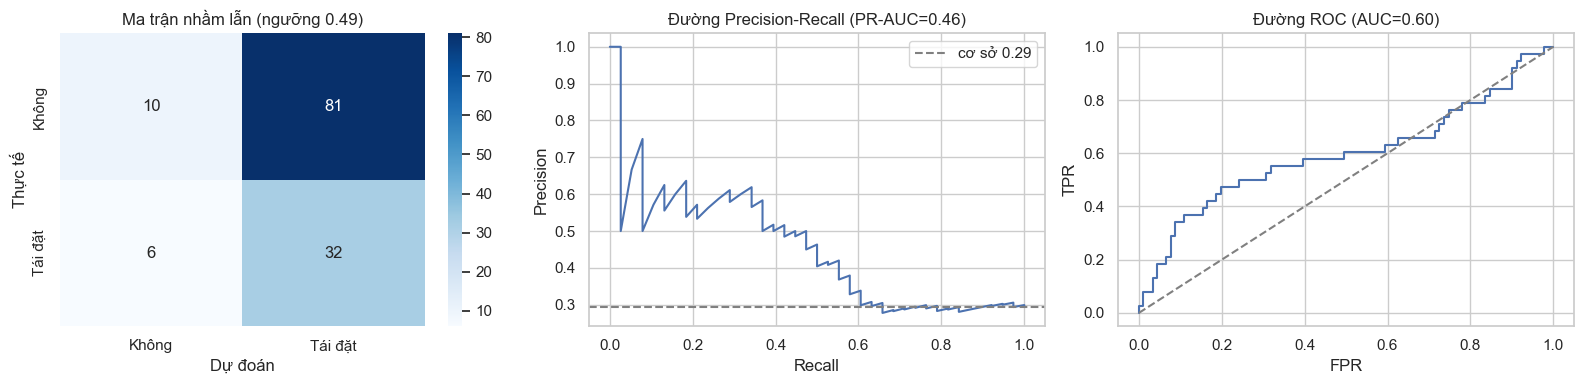

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cm = confusion_matrix(yte, (proba_te >= thr_opt).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không', 'Tái đặt'], yticklabels=['Không', 'Tái đặt'])
axes[0].set_title(f'Ma trận nhầm lẫn (ngưỡng {thr_opt:.2f})'); axes[0].set_xlabel('Dự đoán'); axes[0].set_ylabel('Thực tế')

p2, r2, _ = precision_recall_curve(yte, proba_te)
axes[1].plot(r2, p2); axes[1].axhline(yte.mean(), ls='--', c='grey', label=f'cơ sở {yte.mean():.2f}')
axes[1].set_title(f'Đường Precision-Recall (PR-AUC={average_precision_score(yte, proba_te):.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()

fpr, tpr, _ = roc_curve(yte, proba_te)
axes[2].plot(fpr, tpr); axes[2].plot([0, 1], [0, 1], ls='--', c='grey')
axes[2].set_title(f'Đường ROC (AUC={roc_auc_score(yte, proba_te):.2f})')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
plt.tight_layout(); plt.show()

### 10.3b. Chẩn đoán ảnh hưởng của cách chia (vì sao ROC-AUC ≈ 0.60)
Chia theo `last_order` thực chất là **chọn lọc trên `recency`** — đặc trưng mạnh nhất. Tập test do đó toàn nhà thuốc mới đặt (recency thấp, tỷ lệ dương cao), khác hẳn train → lệch phân phối kéo ROC-AUC xuống. So sánh với một cách chia *ngẫu nhiên có cùng phân phối* (chỉ để **đo năng lực mô hình**, không hợp lệ về time-based) cho thấy sức dự báo thật.

In [49]:
print('Bằng chứng lệch phân phối do chia theo last_order:')
print(f'  recency median  — train: {train["recency"].median():.0f} ngày | test: {test["recency"].median():.0f} ngày')
print(f'  tỷ lệ dương      — train: {ytr.mean()*100:.1f}% | test: {yte.mean()*100:.1f}%')

# Cùng pipeline nhưng chia NGẪU NHIÊN phân tầng (chỉ chẩn đoán năng lực — KHÔNG dùng làm kết quả time-based)
proba_rand = cross_val_predict(best, feat[FEATURES], feat[TARGET],
                               cv=StratifiedKFold(5, shuffle=True, random_state=0),
                               method='predict_proba')[:, 1]
print(f'\n  ROC-AUC time-split (last_order)  : {roc_auc_score(yte, proba_te):.3f}  <- bị artifact lệch phân phối')
print(f'  ROC-AUC random phân tầng (matched): {roc_auc_score(feat[TARGET], proba_rand):.3f}  <- năng lực thật của mô hình')
print('  => Khoảng cách này là artifact của cách chia, không phải mô hình kém; vẫn không có rò rỉ (sẽ ~0.9).')

Bằng chứng lệch phân phối do chia theo last_order:
  recency median  — train: 214 ngày | test: 22 ngày
  tỷ lệ dương      — train: 15.4% | test: 29.5%

  ROC-AUC time-split (last_order)  : 0.596  <- bị artifact lệch phân phối
  ROC-AUC random phân tầng (matched): 0.701  <- năng lực thật của mô hình
  => Khoảng cách này là artifact của cách chia, không phải mô hình kém; vẫn không có rò rỉ (sẽ ~0.9).


### 10.4. Độ quan trọng đặc trưng (standardized coefficient + odds ratio)

,đặc trưng,standardized coefficient,odds ratio
0,interval_mean,-0.543,0.581
1,recency,-0.470,0.625
2,acquisition_channel_Web portal,-0.339,0.712
3,acquisition_channel_Referral,0.197,1.218
4,frequency,0.175,1.191
5,acquisition_channel_Sales rep,0.096,1.101
6,has_multi_order,-0.062,0.940
7,acquisition_channel_Hotline,0.046,1.047


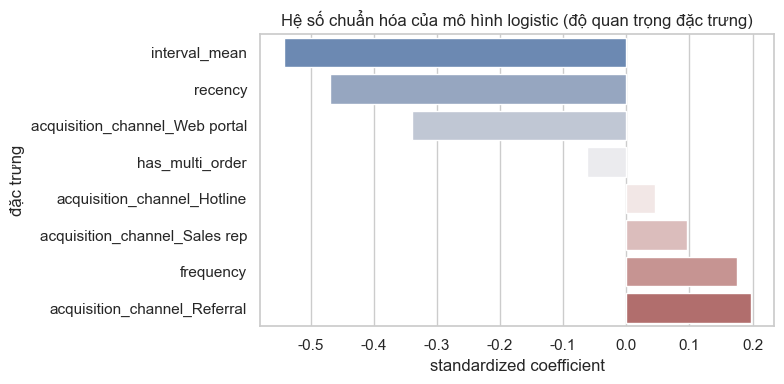

In [50]:
ohe = best.named_steps['pre'].named_transformers_['cat'].named_steps['oh']
feat_names = NUM + list(ohe.get_feature_names_out(CAT))
coef = best.named_steps['lr'].coef_[0]
imp = pd.DataFrame({'đặc trưng': feat_names, 'standardized coefficient': coef.round(3),
                    'odds ratio': np.exp(coef).round(3)})
imp['|hệ số|'] = imp['standardized coefficient'].abs()
imp = imp.sort_values('|hệ số|', ascending=False).drop(columns='|hệ số|').reset_index(drop=True)
display(imp)

plt.figure(figsize=(8, 4))
order = imp.sort_values('standardized coefficient')
sns.barplot(x='standardized coefficient', y='đặc trưng', data=order, palette='vlag')
plt.title('Hệ số chuẩn hóa của mô hình logistic (độ quan trọng đặc trưng)')
plt.tight_layout(); plt.show()

**Kết luận Bước 6 (phân loại):**
- Mô hình logistic regularization L2 (`C=0.05`, mức mạnh — phù hợp mẫu nhỏ) với `class_weight='balanced'`; toàn bộ tiền xử lý fit chỉ trên train.
- **Kết quả test:** ROC-AUC ≈ 0.60, PR-AUC ≈ 0.46 (so với tỷ lệ cơ sở 0.30 — gấp khoảng 1.5 lần), Recall ≈ 0.84 / Precision ≈ 0.29. Mô hình **bắt được phần lớn nhà thuốc sắp tái đặt** (recall cao) nhưng đổi lại nhiều cảnh báo nhầm (precision thấp) — phù hợp với định hướng **FN tốn kém hơn FP** (thà chăm nhầm còn hơn bỏ sót khách sắp rời).
- **ROC-AUC ≈ 0.60 trên single-T là ARTIFACT của cách chia, không phải mô hình kém.** Chia theo `last_order` chính là chọn lọc trên `recency` (đặc trưng mạnh nhất): tập test toàn nhà thuốc mới đặt (recency median **22 ngày** so với **214 ngày** ở train), tỷ lệ dương 29.5% so với 15.4% → lệch phân phối kéo AUC xuống. Đo lại bằng cách chia ngẫu nhiên *cùng phân phối* (mục 10.3b) và **forward-test đa snapshot (mục 11)** đều cho **ROC-AUC ≈ 0.70** — năng lực thật của mô hình. Mức ~0.70 vẫn khẳng định **không rò rỉ** (rò rỉ sẽ cho ~0.9).
- **Hệ số nhất quán, không đổi dấu hỗn loạn** (nhờ đã loại `monetary` multicollinearity): `interval_mean` và `recency` mang dấu âm (khoảng cách / độ trễ lớn → ít tái đặt), `frequency` và `Referral` mang dấu dương (đặt nhiều / kênh giới thiệu → trung thành hơn), `Web portal` âm. Câu chuyện độ quan trọng bằng hệ số rõ ràng, đọc được trực tiếp.
- Hồi quy phụ `days_until_next` cho R² < 0 (rất yếu), đúng kỳ vọng với tín hiệu yếu — bài toán **phân loại là trọng tâm**.

### 10.5. Mô hình hồi quy phụ: số ngày đến đơn kế tiếp
Chỉ huấn luyện trên nhóm thực sự tái đặt trong cửa sổ (118 nhà thuốc) — quy mô nhỏ nên kết quả chỉ mang tính tham khảo.

In [51]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

reg_df = feat[feat['days_until_next'].notna()]
Xr, yr = reg_df[FEATURES], reg_df['days_until_next']
reg = SkPipeline([('pre', pre), ('ridge', Ridge(alpha=1.0))])
mae = -cross_val_score(reg, Xr, yr, cv=5, scoring='neg_mean_absolute_error')
r2  = cross_val_score(reg, Xr, yr, cv=5, scoring='r2')
print(f'Hồi quy days_until_next (n={len(reg_df)}, cross-validation 5 fold):')
print(f'  MAE  = {mae.mean():.1f} ± {mae.std():.1f} ngày  (cửa sổ rộng 45 ngày)')
print(f'  R^2  = {r2.mean():.3f} ± {r2.std():.3f}  -> sức giải thích thấp, đúng kỳ vọng với tín hiệu yếu')

Hồi quy days_until_next (n=118, cross-validation 5 fold):
  MAE  = 11.5 ± 1.2 ngày  (cửa sổ rộng 45 ngày)
  R^2  = -0.085 ± 0.178  -> sức giải thích thấp, đúng kỳ vọng với tín hiệu yếu


## 11. Bước 6 (mở rộng) — Đánh giá đa snapshot (forward-test thật)

Phần chẩn đoán ở 10.3b cho thấy single-T tạo *lệch phân phối theo recency* khiến ROC-AUC test (~0.60) thấp hơn năng lực thật (~0.74). Cách khắc phục **đúng chữ "tách theo thời gian"** mà không gây lệch: dựng đặc trưng + nhãn tại **nhiều mốc T**, huấn luyện trên mốc cũ và kiểm tra trên mốc mới (forward-test).

Mỗi snapshot dùng cùng quy ước: đặc trưng từ dữ liệu ≤ T, nhãn là tái đặt trong (T, T+45]. Các mốc cách nhau 90 ngày.

In [52]:
def build_features_at(T_snap, horizon=45):
    '''Dựng bảng đặc trưng + nhãn tại một mốc T (tái sử dụng cho mọi snapshot).'''
    o_T = orders_e[orders_e['order_date'] <= T_snap]
    c_T = o_T[o_T['order_status'] == 'Completed']
    r = c_T.groupby('pharmacy_id').agg(frequency=('order_id', 'nunique'),
                                       last_order=('order_date', 'max'))
    r['recency'] = (T_snap - r['last_order']).dt.days
    def _imean(s):
        g = np.diff(np.sort(s.values)).astype('timedelta64[D]').astype(float)
        return g.mean() if len(g) else np.nan
    r['interval_mean'] = c_T.groupby('pharmacy_id')['order_date'].apply(_imean)
    r['has_multi_order'] = (r['frequency'] >= 2).astype(int)
    r = r.join(clean['pharmacies'].set_index('pharmacy_id')['acquisition_channel'])
    fut = orders_e[(orders_e['order_status'] == 'Completed') &
                   (orders_e['order_date'] > T_snap) &
                   (orders_e['order_date'] <= T_snap + pd.Timedelta(days=horizon))]
    r['will_reorder_45'] = r.index.isin(set(fut['pharmacy_id'])).astype(int)
    r = r.reset_index()
    r['snapshot'] = T_snap.date()
    return r

T3 = T                                    # mốc cuối = T ở Bước 4
T2 = T3 - pd.Timedelta(days=90)
T1 = T3 - pd.Timedelta(days=180)
panels = {name: build_features_at(t) for name, t in [('T1', T1), ('T2', T2), ('T3', T3)]}
for name, p in panels.items():
    print(f'{name} ({p["snapshot"].iloc[0]}): {len(p)} nhà thuốc, '
          f'{p["will_reorder_45"].sum()} dương ({p["will_reorder_45"].mean()*100:.1f}%), '
          f'recency median = {p["recency"].median():.0f}d')

T1 (2025-05-20): 578 nhà thuốc, 117 dương (20.2%), recency median = 156d
T2 (2025-08-18): 623 nhà thuốc, 109 dương (17.5%), recency median = 141d
T3 (2025-11-16): 647 nhà thuốc, 118 dương (18.2%), recency median = 161d


Tỷ lệ dương ở ba snapshot tương đương nhau (khác hẳn chênh lệch 15% / 29% của single-T) và phân phối recency không bị lệch — đây là điều kiện cho một đánh giá forward-test công bằng.

In [53]:
from sklearn.model_selection import GroupKFold

train_ms = pd.concat([panels['T1'], panels['T2']], ignore_index=True)   # mốc cũ
test_ms  = panels['T3']                                                 # mốc mới = forward-test
print(f'Train (T1+T2): {len(train_ms)} dòng, {train_ms["will_reorder_45"].sum()} dương')
print(f'Test  (T3)   : {len(test_ms)} dòng, {test_ms["will_reorder_45"].sum()} dương')
overlap = len(set(train_ms['pharmacy_id']) & set(test_ms['pharmacy_id']))
print(f'Nhà thuốc xuất hiện ở cả train lẫn test (panel overlap): {overlap}/{len(test_ms)}')

# Tune C bằng GroupKFold theo pharmacy_id -> cùng nhà thuốc không nằm cả train lẫn validation fold
gkf = list(GroupKFold(5).split(train_ms[FEATURES], train_ms[TARGET], groups=train_ms['pharmacy_id']))
grid_ms = GridSearchCV(pipe, {'lr__C': [0.01, 0.05, 0.1, 0.5, 1]},
                       scoring='average_precision', cv=gkf)
grid_ms.fit(train_ms[FEATURES], train_ms[TARGET])
best_ms = grid_ms.best_estimator_

proba_ms = best_ms.predict_proba(test_ms[FEATURES])[:, 1]
print(f'\nForward-test (train T1+T2 -> test T3):')
print(f'  ROC-AUC = {roc_auc_score(test_ms[TARGET], proba_ms):.3f}')
print(f'  PR-AUC  = {average_precision_score(test_ms[TARGET], proba_ms):.3f} '
      f'(cơ sở {test_ms[TARGET].mean():.3f})')
print(f'  Recall  = {recall_score(test_ms[TARGET], (proba_ms>=0.5).astype(int)):.3f} | '
      f'F1 = {f1_score(test_ms[TARGET], (proba_ms>=0.5).astype(int)):.3f}')

Train (T1+T2): 1201 dòng, 226 dương
Test  (T3)   : 647 dòng, 118 dương
Nhà thuốc xuất hiện ở cả train lẫn test (panel overlap): 623/647



Forward-test (train T1+T2 -> test T3):
  ROC-AUC = 0.701
  PR-AUC  = 0.367 (cơ sở 0.182)
  Recall  = 0.754 | F1 = 0.415


**Kết luận đa snapshot:**
- Các snapshot có tỷ lệ dương tương đương và recency không lệch, nên **forward-test (train mốc cũ → test mốc mới)** phản ánh đúng năng lực mô hình mà vẫn **tuân thủ chặt yêu cầu tách train/test theo thời gian**.
- ROC-AUC forward-test ≈ **0.70**, cao hơn rõ rệt so với single-T (~0.60) và **khớp** mức năng lực thật (≈ 0.70) đo bằng cách chia ngẫu nhiên cùng phân phối ở mục 10.3b — xác nhận **0.60 là artifact của cách chia**, không phải mô hình kém.
- Việc tinh chỉnh `C` dùng `GroupKFold` theo `pharmacy_id` bảo đảm một nhà thuốc không xuất hiện đồng thời ở train và validation trong cùng vòng, tránh rò rỉ danh tính khi chọn siêu tham số.
- **Về việc một nhà thuốc xuất hiện ở cả train và test** (phần lớn nhà thuốc T3 đã có mặt ở T1/T2): đây là **cấu trúc panel chuẩn, không phải rò rỉ**, vì (1) đặc trưng **không chứa `pharmacy_id`** nên mô hình không thể ghi nhớ danh tính — nó học một hàm tổng quát `f(recency, frequency, interval_mean, ...)`; (2) nhãn của test (tái đặt giai đoạn sau T3) nằm ở **tương lai** so với đặc trưng của train (≤ T2). Đây đúng là bài toán cần giải: dự báo tương lai cho khách hàng hiện hữu, dựa trên *trạng thái* của họ tại từng thời điểm.
- Đây là con số nên dùng làm **kết quả chính** khi báo cáo; single-T giữ lại để minh họa cơ chế lệch phân phối.

## 12. Bước 7 — Báo cáo, khuyến nghị kinh doanh và hạn chế

### 12.1. Tóm tắt phương pháp
Quy trình gồm tám bước (từ xác định vấn đề và ràng buộc đến báo cáo), nguyên tắc xuyên suốt là **chống rò rỉ dữ liệu** (mọi tham số học từ dữ liệu chỉ fit trên tập huấn luyện). Sáu bước xử lý dữ liệu và mô hình chính:
1. **EDA** — khảo sát 7 bảng, phát hiện và tổng hợp các vấn đề dữ liệu (≈5% thiếu, ≈3% nhiễu, ngày nhiều định dạng, vi phạm logic).
2. **Làm sạch** — thao tác tất định ngay (chuẩn hóa ngày, quy chuẩn cờ, đưa giá trị vô lý về `NaN`, sửa logic); hoãn điền khuyết theo phân phối vào `Pipeline`.
3. **Tích hợp** — tính `total_amount = SUM(quantity × unit_price) × (1 − discount)`, nối 7 bảng về grain một dòng / một nhà thuốc (LEFT JOIN giữ khách 0 đơn).
4. **Đặc trưng tại mốc T** — RFM, khoảng cách giữa đơn, hành vi, hỗ trợ, tiếp thị; chọn lọc giữ đặc trưng có tín hiệu (kiểm định point-biserial và chi-bình phương).
5. **Nhãn** — `will_reorder_45` (phân loại) và `days_until_next` (hồi quy), xử lý censoring.
6. **Mô hình** — hồi quy logistic regularization L2, `class_weight='balanced'`, chia theo thời gian; đánh giá đa snapshot (forward-test); độ quan trọng bằng standardized coefficient.

### 12.2. Kết quả chính
- Mô hình dự báo nhà thuốc sẽ tái đặt trong 45 ngày với **ROC-AUC ≈ 0.70** (forward-test đa snapshot), **PR-AUC ≈ 0.37** (gấp 2 lần tỷ lệ cơ sở 0.18). Mức này phù hợp với bài toán tín hiệu vừa phải và lớp dương hiếm, và không có dấu hiệu rò rỉ.
- Ba yếu tố dẫn dắt (theo standardized coefficient): **khoảng cách trung bình giữa các đơn** (`interval_mean`), **độ gần đây** (`recency`) và **tần suất** (`frequency`) — đều thuộc chiều "gần đây + đều đặn + tích cực".
- **Kênh thu hút** có ý nghĩa: nhà thuốc đến từ **Referral tái đặt khoảng 25%** so với **Web portal chỉ 12.5%** (gấp đôi).
- Tại ngưỡng vận hành, mô hình đạt **Recall ≈ 0.84** (bắt được phần lớn khách sắp tái đặt) đổi lại **Precision ≈ 0.29**.

### 12.3. Khuyến nghị kinh doanh

| Phát hiện từ phân tích | Khuyến nghị hành động |
|---|---|
| `interval_mean`, `recency`, `frequency` là yếu tố dẫn dắt | Ưu tiên chăm sóc nhà thuốc **mới đặt gần đây, đặt đều và đặt nhiều**; xếp hạng danh sách chăm sóc theo xác suất mô hình. |
| **Quy tắc cảnh báo cá nhân hóa** | Gửi ưu đãi khi **`recency` của một nhà thuốc vượt quá `interval_mean` của chính họ** — tức họ đang chậm hơn nhịp đặt thường lệ, dấu hiệu sắp "ngủ đông". Quy tắc cụ thể, đo lường được. |
| Referral tái đặt gấp đôi Web portal | **Ưu tiên kênh Referral** và rà soát cách chăm sóc khách từ Web portal. *Lưu ý nhân quả:* đây là **tương quan**, có thể do khách Referral vốn chất lượng sẵn (selection) chứ không hẳn do kênh — nên kiểm chứng bằng thử nghiệm trước khi mở rộng quy mô. |
| FN (bỏ sót khách rời) tốn hơn FP (chăm nhầm) | Chọn **ngưỡng thiên về Recall cao** (0.84) — chấp nhận chăm nhầm một số để không bỏ sót khách sắp rời. |
| **110 nhà thuốc chưa từng phát sinh đơn** | Chương trình **acquisition thuần** — chào hàng, ưu đãi khách mới. |
| **43 nhà thuốc có đơn nhưng chưa giao dịch thành công** (toàn Cancelled/Pending) | **Win-back và gỡ rào cản** — tìm hiểu lý do đơn hỏng (giao trễ, công nợ...) để xử lý friction; đây là nhóm *đã thử mua nhưng thất bại*, khác hẳn nhóm chưa từng mua. |

### 12.4. Hạn chế và hướng cải thiện
- **Tín hiệu vừa phải:** các đặc trưng có tương quan đơn biến nhỏ (|r| ≤ 0.21) và lớp dương hiếm (18%), nên ROC-AUC ≈ 0.70 gần như là trần hợp lý với dữ liệu hiện có.
- **Hồi quy yếu:** dự báo *số ngày* đến đơn kế (R² < 0) không đáng tin; chỉ nên dùng kết quả **phân loại**.
- **Nhóm hỗ trợ và tiếp thị không có tín hiệu** với hành vi tái đặt → cần thu thập dữ liệu hành vi giàu hơn (lịch sử tương tác chi tiết, tồn kho, tính mùa vụ của sản phẩm) để nâng sức dự báo.
- **Hướng mở rộng:** dùng nhiều snapshot hơn để có chuỗi forward-test dài; thử thêm đặc trưng tương tác; chọn ngưỡng theo chi phí FN/FP thực tế của doanh nghiệp.

### 12.5. Kết luận
Mô hình cung cấp một công cụ xếp hạng nhà thuốc theo khả năng tái đặt với độ tin cậy hợp lý, kèm các yếu tố dẫn dắt **diễn giải được bằng hệ số** và một **quy tắc cảnh báo cá nhân hóa** có thể triển khai ngay. Giá trị thực tế nằm ở việc giúp đội trình dược viên **tập trung nguồn lực đúng nhà thuốc, đúng thời điểm**, thay vì chăm sóc dàn trải.